# Title - Decoding Endometrial Cancer Through RNA-Seq & Interpretable ML


## Setup

In [1]:
import subprocess, sys
for pkg in ['pandas','numpy','scipy','matplotlib','seaborn',
            'scikit-learn','lifelines','xgboost']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'], check=False)


In [2]:
import os, warnings
import re
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_auc_score)
from xgboost import XGBClassifier
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from collections import Counter
import gseapy as gp
warnings.filterwarnings('ignore')

# Color palette 
PAL = {'POLE':'#10B981','MSI':'#3B82F6','NSMP':'#F59E0B','CNV':'#EF4444',
       'teal':'#0D9488','navy':'#0D1B2A','gray':'#94A3B8'}
SUBTYPE_ORDER  = ['NSMP','MSI','CNV','POLE']
SUBTYPE_COLORS = [PAL['NSMP'], PAL['MSI'], PAL['CNV'], PAL['POLE']]
full_labels = {'NSMP':'NSMP / CNV-Low','MSI':'MSI-High (MMRd)',
               'CNV':'CNV-High / p53abn','POLE':'POLE Ultramutated'}

plt.rcParams.update({
    'figure.dpi':150,'savefig.dpi':300,'font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,
    'figure.facecolor':'white','axes.facecolor':'white',
})
FIG_DIR = '../results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')
    plt.show()

print('Setup complete.')


Setup complete.


## 1. Loading Data

In [3]:
DATA_DIR = '../data/raw/TCGA_UCEC_data'   

print('Loading files...\n')
counts_raw = pd.read_csv(f'{DATA_DIR}/ucec_rnaseq_counts.csv', index_col=0)
tpm_raw    = pd.read_csv(f'{DATA_DIR}/ucec_rnaseq_tpm.csv', index_col=0)
gene_meta  = pd.read_csv(f'{DATA_DIR}/ucec_gene_metadata.csv', index_col=0)
subtypes   = pd.read_csv(f'{DATA_DIR}/ucec_molecular_subtypes.csv')
clinical   = pd.read_csv(f'{DATA_DIR}/ucec_clinical_gdc.csv',
                         engine='python', on_bad_lines='skip')

print(f'counts_raw: {counts_raw.shape[0]:,} genes x {counts_raw.shape[1]:,} samples')
print(f'tpm_raw:    {tpm_raw.shape[0]:,} genes x {tpm_raw.shape[1]:,} samples')
print(f'gene_meta:  {gene_meta.shape[0]:,} genes')
print(f'subtypes:   {subtypes.shape[0]:,} patients x {subtypes.shape[1]:,} columns')
print(f'clinical:   {clinical.shape[0]:,} patients')
print('\nAll files loaded')


Loading files...

counts_raw: 60,660 genes x 553 samples
tpm_raw:    60,660 genes x 553 samples
gene_meta:  60,660 genes
subtypes:   373 patients x 19 columns
clinical:   520 patients

All files loaded


## 2. Data Verification

In [4]:
# 2a. Gene verification 
print('=== GENE VERIFICATION ===')
print(f'Total genes:                {counts_raw.shape[0]:>8,}')
zero_genes = (counts_raw.sum(axis=1) == 0).sum()
print(f'Zero-count genes:           {zero_genes:>8,}')
expressed = (counts_raw > 0).sum(axis=1) >= int(counts_raw.shape[1] * 0.20)
print(f'Expressed in >=20% samples: {expressed.sum():>8,}  <- model input')
if 'gene_type' in gene_meta.columns:
    pc = (gene_meta['gene_type'] == 'protein_coding').sum()
    print(f'Protein-coding genes:       {pc:>8,}')


=== GENE VERIFICATION ===
Total genes:                  60,660
Zero-count genes:              2,960
Expressed in >=20% samples:   38,933  <- model input
Protein-coding genes:         19,962


In [5]:
# 2b. Sample verification 
print('=== SAMPLE VERIFICATION ===')
print(f'Total RNA-seq samples:      {counts_raw.shape[1]:>8,}')
patient_barcodes = set(s[:12] for s in counts_raw.columns)
print(f'Unique patients (12-char):  {len(patient_barcodes):>8,}')
dups = {p:n for p,n in Counter(s[:12] for s in counts_raw.columns).items() if n > 1}
print(f'Patients with >1 aliquot:   {len(dups):>8,}')
print(f'Subtype labels available:   {len(subtypes):>8,}')


=== SAMPLE VERIFICATION ===
Total RNA-seq samples:           553
Unique patients (12-char):       545
Patients with >1 aliquot:          4
Subtype labels available:        373


In [6]:
print(subtypes['vital_status'].head()) # 'OS days' (column after 'vital_status') values
print("\n")
print(subtypes['histology_grade'].head()) # 'vital status' values

TCGA-A5-A0G1       3251
TCGA-A5-A0G2    Unknown
TCGA-A5-A0G3       1428
TCGA-A5-A0G5       1126
TCGA-A5-A0G9       2540
Name: vital_status, dtype: object


TCGA-A5-A0G1    DECEASED
TCGA-A5-A0G2     Unknown
TCGA-A5-A0G3      LIVING
TCGA-A5-A0G5      LIVING
TCGA-A5-A0G9      LIVING
Name: histology_grade, dtype: object


In [7]:
# 2c. Building master sample table 
# The TCGA 2013 paper supplementary CSV has ALL columns shifted by one when calling a particular column (Verified in the cell above)
# True column mapping:
#   Column 'vital_status'       -> contains OS days  (e.g. 3251, 1428)
#   Column 'os_days'            -> contains disease status (NoDisease/WithDisease)
#   Column 'histology_grade'    -> contains vital status (LIVING/DECEASED)
#   Column 'histology'          -> contains grade (Grade 1/2/3)
#   Column 'age'                -> contains stage (Stage I/II/III/IV)

def recode_subtype(val):
    if pd.isna(val): return np.nan
    v = str(val).upper().strip()
    if 'POLE'    in v: return 'POLE'
    if 'MSI'     in v: return 'MSI'
    if 'CN HIGH' in v: return 'CNV'
    if 'CN LOW'  in v: return 'NSMP'
    return np.nan   # MSS, Notassigned → exclude

subtypes['subtype_clean'] = subtypes['IntegrativeCluster'].apply(recode_subtype)
print('Recoded subtypes:')
print(subtypes['subtype_clean'].value_counts(dropna=False))

# subtypes index = 12-char patient barcodes; RNA-seq columns = 28-char -> truncate
sample_patient = pd.DataFrame({
    'sample_barcode': counts_raw.columns.tolist(),
    'patient_12':     [s[:12] for s in counts_raw.columns]
})
sub_small = subtypes[['subtype_clean']].copy()
sub_small.index.name = 'patient_12'

master = sample_patient.merge(sub_small, left_on='patient_12',
                               right_index=True, how='left')

# Merging clinical columns - use correct column names (shifted dataset)
clin_avail = [c for c in ['vital_status','os_days','pfs_days','age',
                           'tumor_grade','X2009stagegroup','histology',
                           'histology_grade','race','ethnicity']
              if c in subtypes.columns]
master = master.merge(subtypes[clin_avail], left_on='patient_12',
                      right_index=True, how='left')
master = master.set_index('sample_barcode')

# Fixing the swapped column names 
master = master.rename(columns={
    'vital_status':    'os_days_str',       # actually: OS days as string
    'os_days':         'disease_status',    # actually: NoDisease/WithDisease
    'pfs_days':        'pfs_days_str',      # actually: PFS days as string
    'age':             'stage',             # actually: Stage I/II/III/IV
    'X2009stagegroup': 'histology_type',    # actually: Endometrioid/Serous
    'histology':       'grade',             # actually: Grade 1/2/3
    'tumor_grade':     'histology_grade',   # actually: EndoGr1/SerousGr3
    'histology_grade': 'vital_status_true', # actually: LIVING/DECEASED
})

# Building numeric survival columns
master['os_days_num']  = pd.to_numeric(master['os_days_str'],  errors='coerce')
master['pfs_days_num'] = pd.to_numeric(master['pfs_days_str'], errors='coerce')
master['event'] = np.where(
    master['vital_status_true'].str.upper().str.strip() == 'DECEASED', 1.0,
    np.where(master['vital_status_true'].str.upper().str.strip() == 'LIVING', 0.0, np.nan)
)

print(f'\nMaster shape: {master.shape}')
print('subtype_clean:')
print(master['subtype_clean'].value_counts(dropna=False))


Recoded subtypes:
subtype_clean
NaN     144
NSMP     88
MSI      67
CNV      57
POLE     17
Name: count, dtype: int64

Master shape: (553, 15)
subtype_clean:
subtype_clean
NaN     320
NSMP     88
MSI      67
CNV      61
POLE     17
Name: count, dtype: int64


In [8]:
# 2d. Labeled subset 
labeled  = master[master['subtype_clean'].notna()].index
meta_lab = master.loc[labeled]
counts   = counts_raw.T.loc[labeled]
tpm      = tpm_raw.T.loc[labeled]

print(f'Labeled samples: {len(labeled)}')
print(f'counts shape:    {counts.shape}')
print(f'\nSubtype breakdown:')
print(meta_lab['subtype_clean'].value_counts())
print(f'\nSurvival data:')
print(f'os_days_num non-null: {meta_lab["os_days_num"].notna().sum()}')
print(f'event non-null:       {meta_lab["event"].notna().sum()}')
print(f'event counts:')
print(meta_lab['event'].value_counts(dropna=False))

Labeled samples: 233
counts shape:    (233, 60660)

Subtype breakdown:
subtype_clean
NSMP    88
MSI     67
CNV     61
POLE    17
Name: count, dtype: int64

Survival data:
os_days_num non-null: 233
event non-null:       233
event counts:
event
0.0    212
1.0     21
Name: count, dtype: int64


## 3. Clinical Data - Missing data

Saved: ../results/figures/clinical_missingness.png


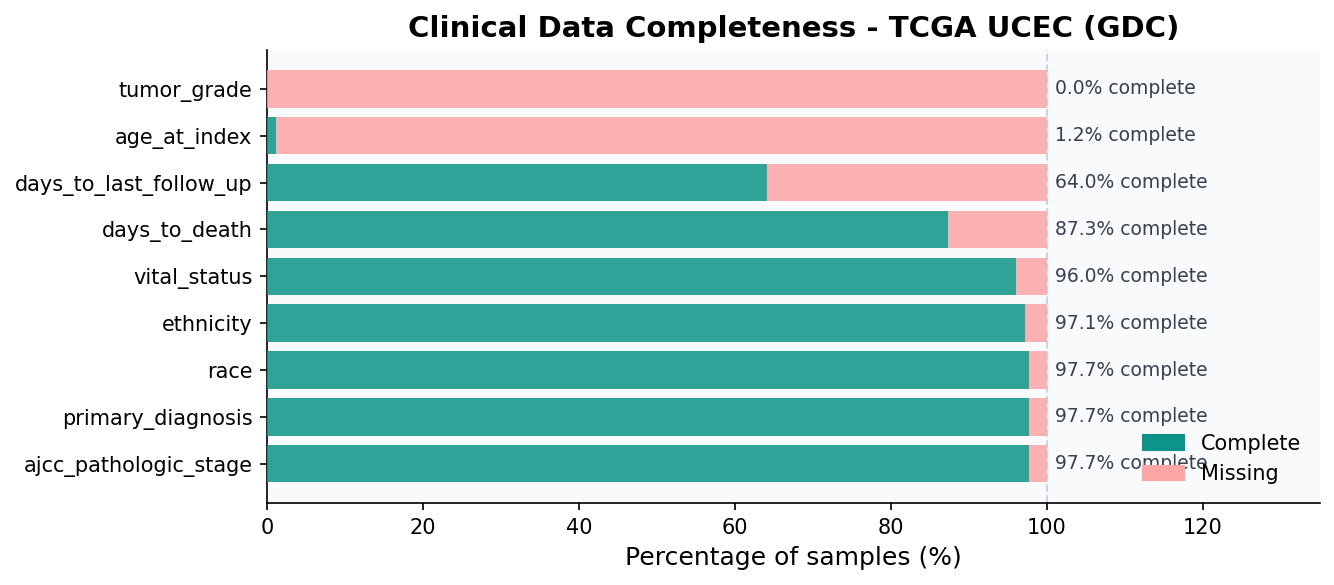

In [9]:
key_cols = ['vital_status','days_to_death','days_to_last_follow_up',
            'age_at_index','tumor_grade','ajcc_pathologic_stage',
            'primary_diagnosis','race','ethnicity','gender']
# Filtering to columns that actually exist in the GDC clinical file
avail = [c for c in key_cols if c in clinical.columns]
clin_sub = clinical[avail].copy()

miss_pct = clin_sub.isnull().mean() * 100
miss_df  = miss_pct.reset_index()
miss_df.columns = ['Variable','Missing_%']
miss_df['Complete_%'] = 100 - miss_df['Missing_%']
miss_df = miss_df.sort_values('Missing_%')

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(miss_df['Variable'], miss_df['Complete_%'],
        color=PAL['teal'], alpha=0.85, zorder=3)
ax.barh(miss_df['Variable'], miss_df['Missing_%'],
        left=miss_df['Complete_%'], color='#FCA5A5', alpha=0.85,
        zorder=3, label='Missing')
for i2, (_, row) in enumerate(miss_df.iterrows()):
    ax.text(101, i2, f"{row['Complete_%']:.1f}% complete",
            va='center', fontsize=9, color='#374151')
ax.set_xlabel('Percentage of samples (%)')
ax.set_title('Clinical Data Completeness - TCGA UCEC (GDC)', fontweight='bold')
ax.set_xlim(0, 135)
ax.axvline(100, color='#CBD5E1', lw=1, ls='--', zorder=2)
ax.set_facecolor('#F8FAFC')
legend_p = [mpatches.Patch(color=PAL['teal'], label='Complete'),
            mpatches.Patch(color='#FCA5A5', label='Missing')]
ax.legend(handles=legend_p, loc='lower right', frameon=False)
plt.tight_layout()
savefig('clinical_missingness.png')


## 4. Subtype Distribution

Saved: ../results/figures/subtype_distribution.png


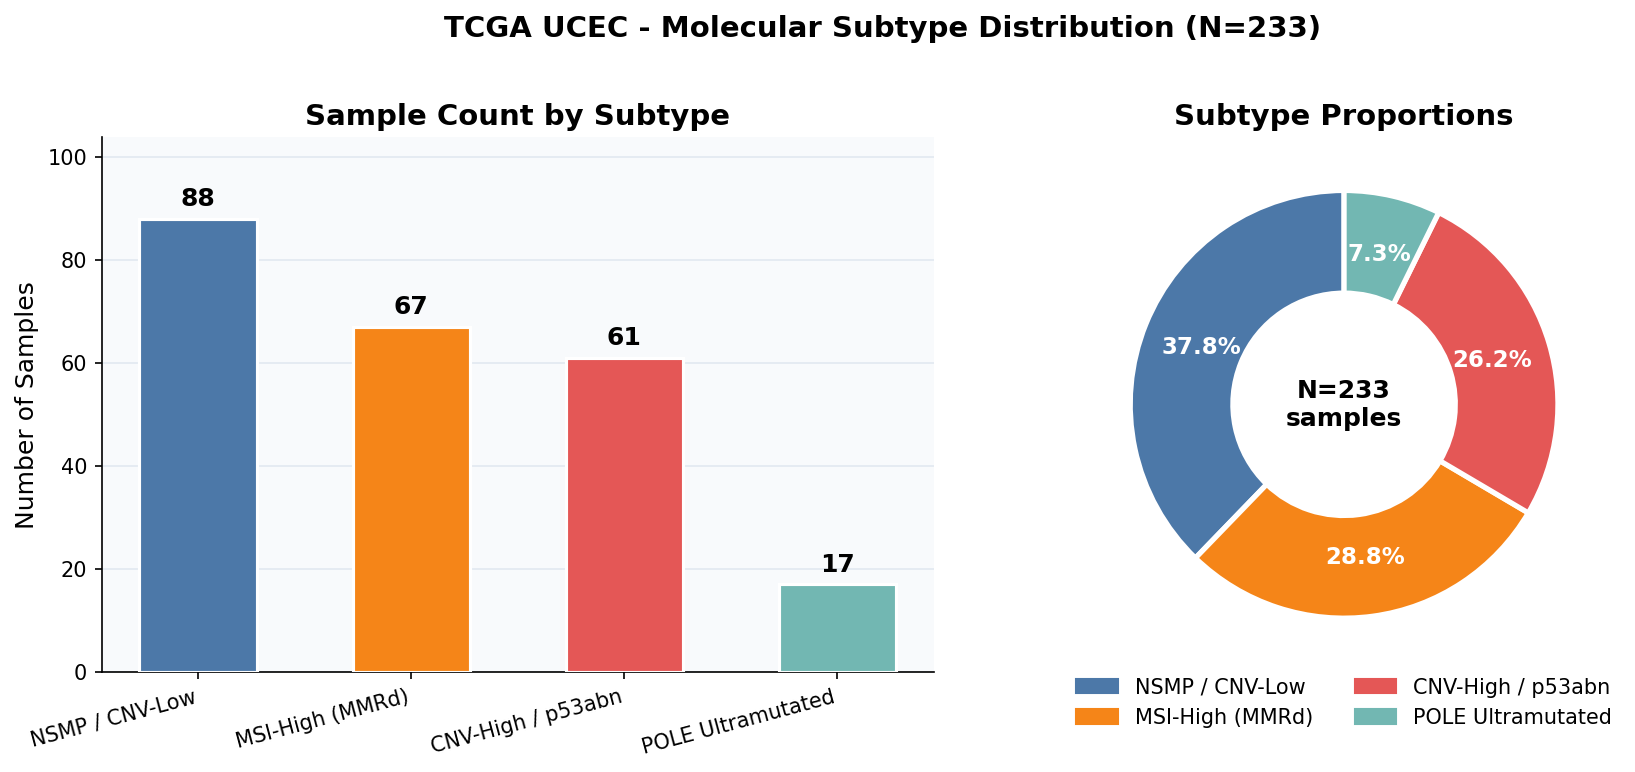

In [10]:
subtype_counts = (meta_lab['subtype_clean'].value_counts()
                  .reindex(SUBTYPE_ORDER).fillna(0).astype(int))
colors = {'NSMP':'#4C78A8','MSI':'#F58518','CNV':'#E45756','POLE':'#72B7B2'}
SUBTYPE_COLORS = [colors[s] for s in SUBTYPE_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
ax = axes[0]
x_pos = np.arange(len(SUBTYPE_ORDER))
bars = ax.bar(x_pos, subtype_counts.values, color=SUBTYPE_COLORS,
              edgecolor='white', linewidth=1.5, width=0.55, zorder=3)
ax.set_facecolor('#F8FAFC')
ax.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax.set_axisbelow(True)
ax.set_xticks(x_pos)
ax.set_xticklabels([full_labels[s] for s in SUBTYPE_ORDER], rotation=15, ha='right')
ax.set_ylabel('Number of Samples')
ax.set_title('Sample Count by Subtype', fontweight='bold')
ax.set_ylim(0, max(subtype_counts.values) * 1.18)
for bar, val in zip(bars, subtype_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Donut chart
ax2 = axes[1]
wedges, _, autotexts = ax2.pie(
    subtype_counts.values, colors=SUBTYPE_COLORS, autopct='%1.1f%%',
    startangle=90, pctdistance=0.72,
    wedgeprops=dict(width=0.48, edgecolor='white', linewidth=2.5))
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
ax2.text(0, 0, f'N={subtype_counts.sum()}\nsamples',
         ha='center', va='center', fontsize=12, fontweight='bold')
ax2.set_title('Subtype Proportions', fontweight='bold')
legend_p = [mpatches.Patch(color=c, label=full_labels[s])
            for s, c in zip(SUBTYPE_ORDER, SUBTYPE_COLORS)]
ax2.legend(handles=legend_p, loc='lower center',
           bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)

plt.suptitle('TCGA UCEC - Molecular Subtype Distribution (N=233)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('subtype_distribution.png')


## 5. Expression QC

Saved: ../results/figures/library_size_qc.png


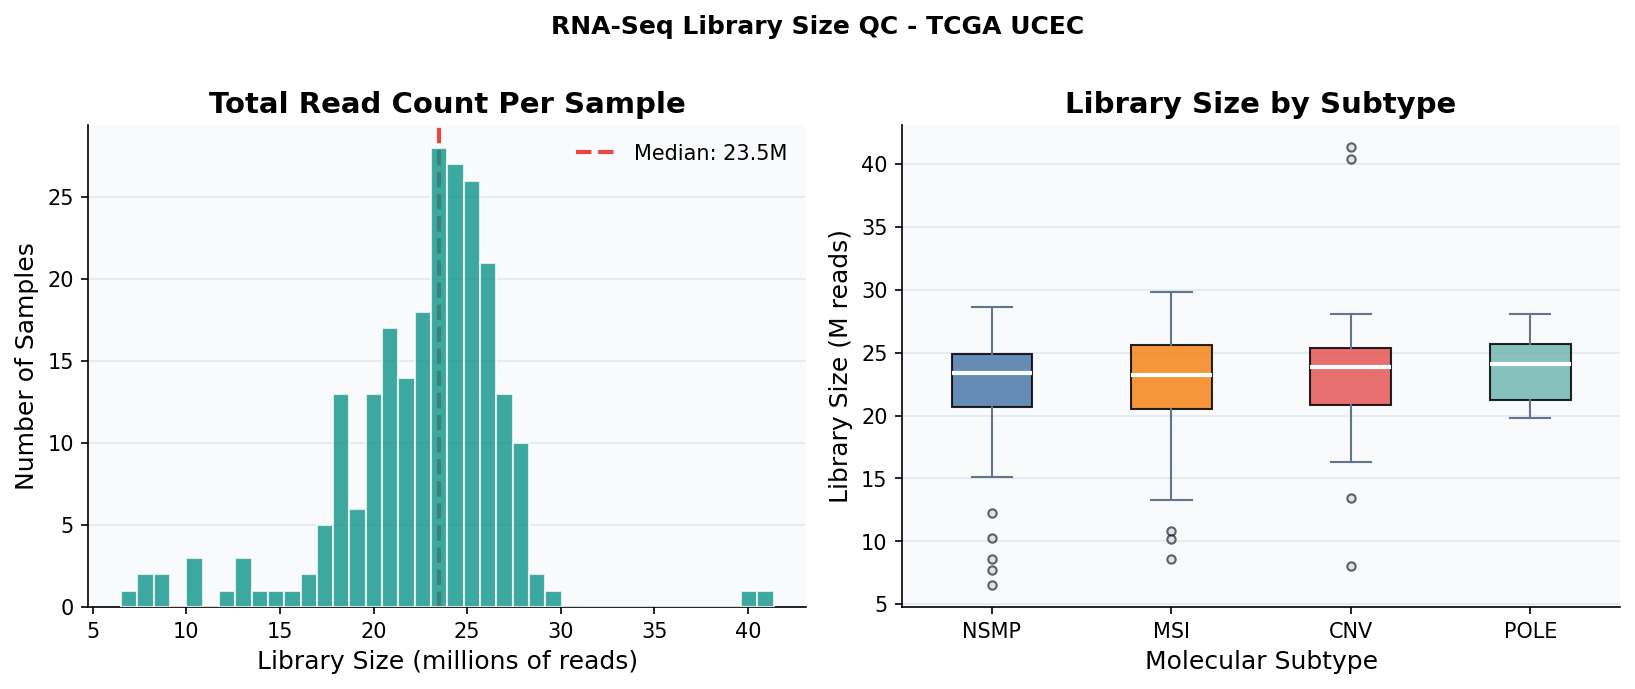

In [11]:
lib_size = counts.sum(axis=1) / 1e6
lib_df   = pd.DataFrame({'library_size_M': lib_size,
                          'subtype': meta_lab['subtype_clean']})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.hist(lib_size, bins=40, color=PAL['teal'], alpha=0.8, edgecolor='white', zorder=3)
ax.axvline(lib_size.median(), color=PAL['CNV'], lw=2, ls='--',
           label=f'Median: {lib_size.median():.1f}M')
ax.set_facecolor('#F8FAFC'); ax.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax.set_xlabel('Library Size (millions of reads)')
ax.set_ylabel('Number of Samples')
ax.set_title('Total Read Count Per Sample', fontweight='bold')
ax.legend(frameon=False)

ax2 = axes[1]
subtype_lib = [lib_df[lib_df['subtype'] == st]['library_size_M'].values
               for st in SUBTYPE_ORDER]
bp = ax2.boxplot(subtype_lib, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#64748B'),
                 capprops=dict(color='#64748B'),
                 flierprops=dict(marker='o', markerfacecolor='#CBD5E1',
                                markersize=4, alpha=0.6))
for patch, col in zip(bp['boxes'], SUBTYPE_COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.85)
ax2.set_facecolor('#F8FAFC'); ax2.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax2.set_xticklabels(SUBTYPE_ORDER)
ax2.set_xlabel('Molecular Subtype')
ax2.set_ylabel('Library Size (M reads)')
ax2.set_title('Library Size by Subtype', fontweight='bold')

plt.suptitle('RNA-Seq Library Size QC - TCGA UCEC', y=1.01, fontweight='bold')
plt.tight_layout()
savefig('library_size_qc.png')


### Gene filtering

Saved: ../results/figures/gene_filtering.png


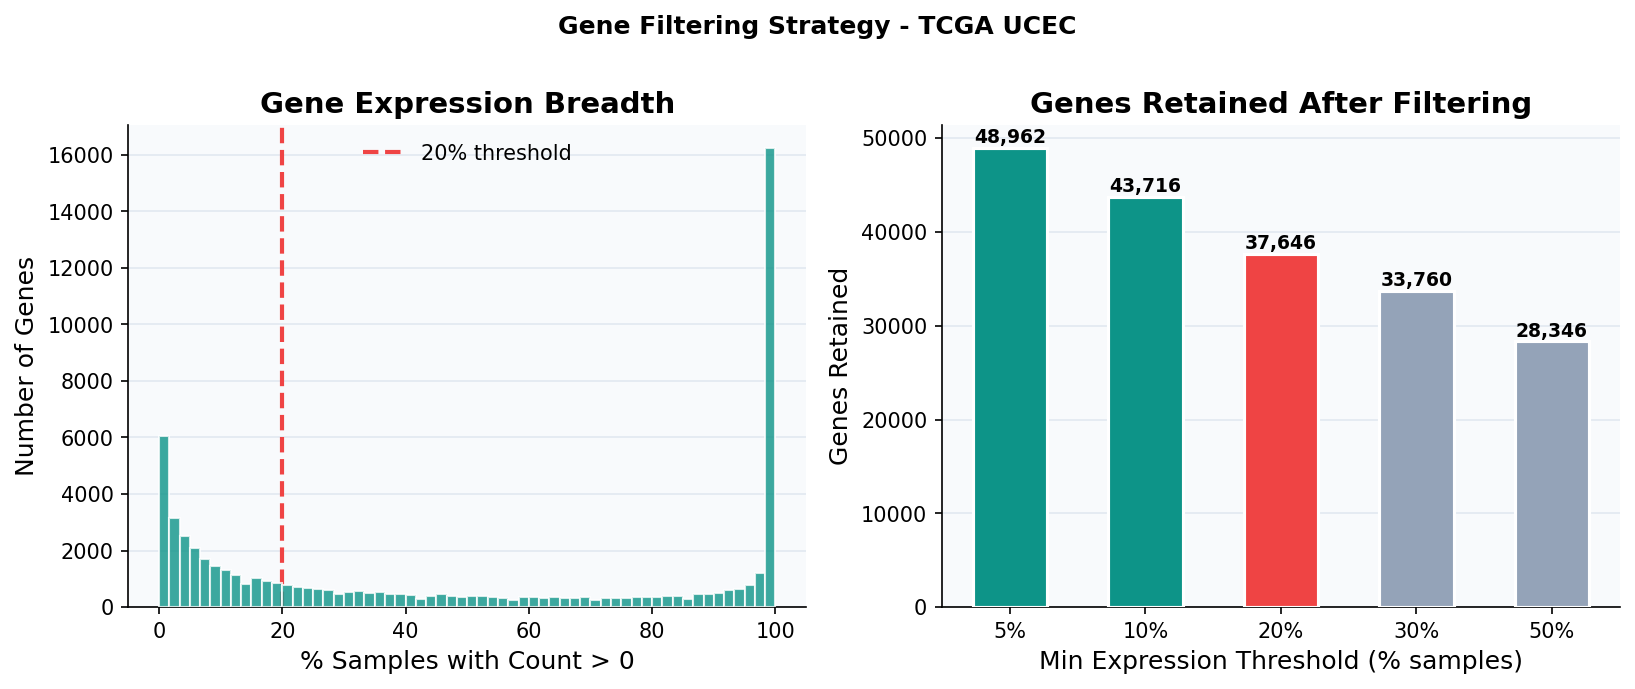

In [12]:
frac_expressed = (counts > 0).mean(axis=0)
thresholds = [0.05, 0.10, 0.20, 0.30, 0.50]
kept = [int((frac_expressed >= t).sum()) for t in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.hist(frac_expressed * 100, bins=60, color=PAL['teal'],
        alpha=0.8, edgecolor='white', zorder=3)
ax.axvline(20, color=PAL['CNV'], lw=2, ls='--', label='20% threshold')
ax.set_facecolor('#F8FAFC'); ax.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax.set_xlabel('% Samples with Count > 0')
ax.set_ylabel('Number of Genes')
ax.set_title('Gene Expression Breadth', fontweight='bold')
ax.legend(frameon=False)

ax2 = axes[1]
bar_colors = [PAL['teal'] if t < 0.20 else PAL['CNV'] if t == 0.20 else PAL['gray']
              for t in thresholds]
bars = ax2.bar([f'{int(t*100)}%' for t in thresholds], kept, color=bar_colors,
               edgecolor='white', linewidth=1.5, zorder=3, width=0.55)
ax2.set_facecolor('#F8FAFC'); ax2.yaxis.grid(True, color='#E2E8F0', zorder=0)
for bar, val in zip(bars, kept):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xlabel('Min Expression Threshold (% samples)')
ax2.set_ylabel('Genes Retained')
ax2.set_title('Genes Retained After Filtering', fontweight='bold')

plt.suptitle('Gene Filtering Strategy - TCGA UCEC', y=1.01, fontweight='bold')
plt.tight_layout()
savefig('gene_filtering.png')


## 6. Log2-TPM Normalization

Genes after 20% filter: 37,646
Saved: ../results/figures/expression_distributions.png


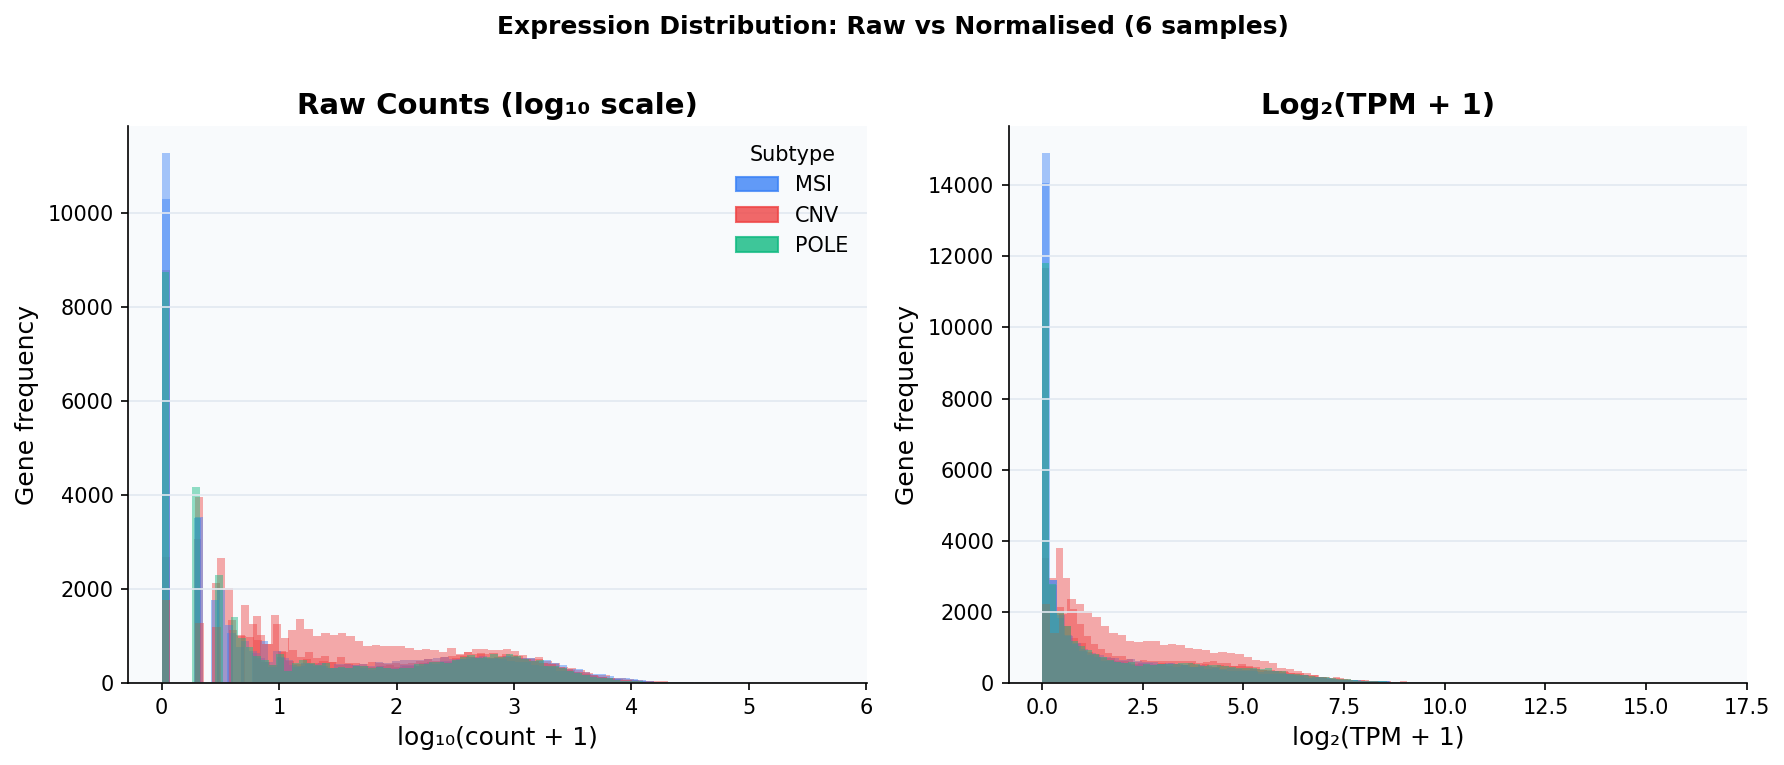

In [13]:
gene_mask = (counts > 0).mean(axis=0) >= 0.20
counts_f  = counts.loc[:, gene_mask]
tpm_f     = tpm.loc[:, gene_mask]
log2tpm   = np.log2(tpm_f + 1)
print(f'Genes after 20% filter: {counts_f.shape[1]:,}')

np.random.seed(42)
sample_idx      = np.random.choice(len(counts_f), 6, replace=False)
sample_ids_viz  = counts_f.index[sample_idx]
sample_subs_viz = meta_lab.loc[sample_ids_viz, 'subtype_clean'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (sid, st) in enumerate(zip(sample_ids_viz, sample_subs_viz)):
    col = PAL.get(st, '#94A3B8')
    axes[0].hist(np.log10(counts_f.loc[sid] + 1), bins=80, alpha=0.45, color=col)
    axes[1].hist(log2tpm.loc[sid], bins=80, alpha=0.45, color=col)

for ax, title, xlabel in zip(axes,
    ['Raw Counts (log₁₀ scale)','Log₂(TPM + 1)'],
    ['log₁₀(count + 1)','log₂(TPM + 1)']):
    ax.set_facecolor('#F8FAFC'); ax.yaxis.grid(True, color='#E2E8F0', zorder=0)
    ax.set_xlabel(xlabel); ax.set_ylabel('Gene frequency')
    ax.set_title(title, fontweight='bold')

legend_p = [mpatches.Patch(color=PAL[s], label=s, alpha=0.8)
            for s in SUBTYPE_ORDER if s in set(sample_subs_viz)]
axes[0].legend(handles=legend_p, frameon=False, title='Subtype')
plt.suptitle('Expression Distribution: Raw vs Normalised (6 samples)',
             fontweight='bold', y=1.01)
plt.tight_layout()
savefig('expression_distributions.png')


## 7. PCA

In [14]:
gene_std = log2tpm.std(axis=0)
top3000  = gene_std.nlargest(3000).index
X_hvg    = log2tpm[top3000]
X_scaled = StandardScaler().fit_transform(X_hvg)

pca    = PCA(n_components=50, random_state=42)
X_pca  = pca.fit_transform(X_scaled)
ev     = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame(X_pca[:, :3], columns=['PC1','PC2','PC3'],
                       index=meta_lab.index)
pca_df['subtype'] = meta_lab['subtype_clean']

print(f'PC1: {ev[0]:.1f}%  PC2: {ev[1]:.1f}%  PC3: {ev[2]:.1f}%')


PC1: 10.4%  PC2: 7.5%  PC3: 6.5%


Saved: ../results/figures/pca_subtypes.png


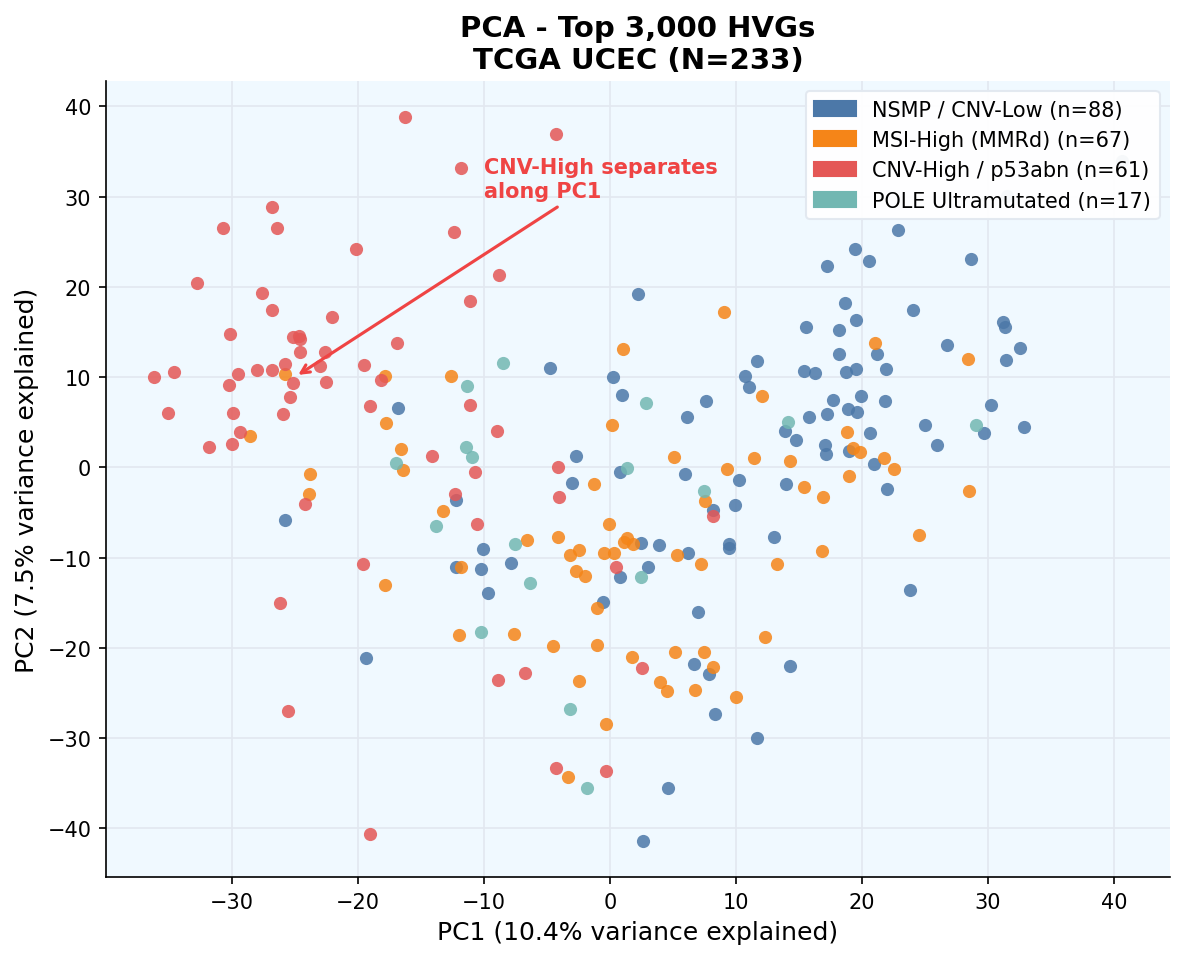

In [15]:
# Fig: PC1 vs PC2 
colors_pca = {'NSMP':'#4C78A8','MSI':'#F58518','CNV':'#E45756','POLE':'#72B7B2'}
n_labels   = {st: int((meta_lab['subtype_clean']==st).sum()) for st in SUBTYPE_ORDER}

fig, ax = plt.subplots(figsize=(8, 6.5))
for st in SUBTYPE_ORDER:
    mask = pca_df['subtype'] == st
    ax.scatter(pca_df.loc[mask,'PC1'], pca_df.loc[mask,'PC2'],
               c=colors_pca[st], s=40, alpha=0.85, linewidths=0,
               label=f'{full_labels[st]} (n={n_labels[st]})', zorder=3)

ax.set_xlabel(f'PC1 ({ev[0]:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({ev[1]:.1f}% variance explained)')
ax.set_title('PCA - Top 3,000 HVGs\nTCGA UCEC (N=233)', fontweight='bold')
ax.set_facecolor('#F0F9FF')
ax.grid(True, color='#E2E8F0', zorder=0)
patches = [mpatches.Patch(color=colors_pca[s], label=f'{full_labels[s]} (n={n_labels[s]})')
           for s in SUBTYPE_ORDER]
ax.legend(handles=patches, frameon=True, framealpha=0.95,
          edgecolor='#E2E8F0', fontsize=10, loc='upper right')
ax.annotate('CNV-High separates\nalong PC1',
            xy=(-25, 10), xytext=(-10, 30),
            arrowprops=dict(arrowstyle='->', color='#EF4444', lw=1.5),
            fontsize=10, color='#EF4444', fontweight='bold')
plt.tight_layout()
savefig('pca_subtypes.png')


### Scree plot

Saved: ../results/figures/scree_plot.png


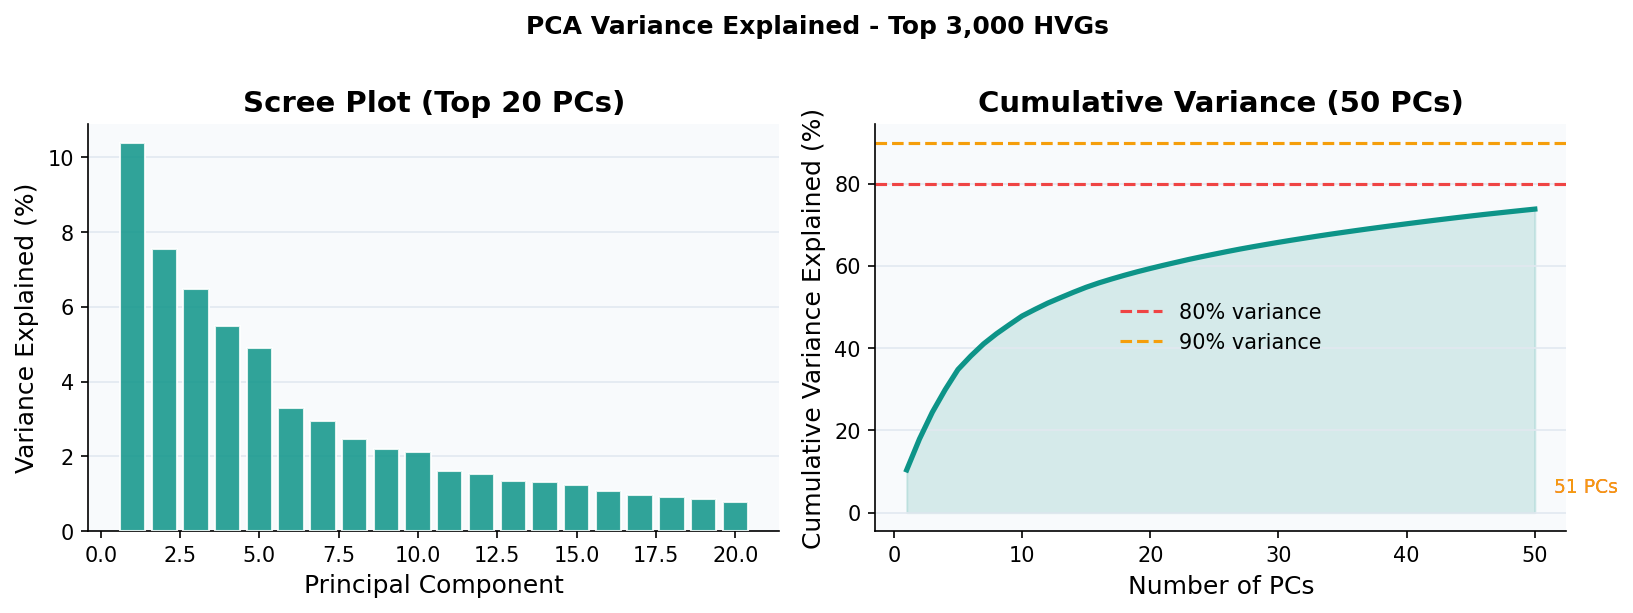

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.bar(range(1, 21), ev[:20], color=PAL['teal'], alpha=0.85,
       edgecolor='white', zorder=3)
ax.set_facecolor('#F8FAFC'); ax.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('Scree Plot (Top 20 PCs)', fontweight='bold')

ax2 = axes[1]
cum_ev = np.cumsum(ev[:50])
ax2.plot(range(1, 51), cum_ev, color=PAL['teal'], lw=2.5, zorder=3)
ax2.fill_between(range(1, 51), cum_ev, alpha=0.15, color=PAL['teal'])
ax2.axhline(80, color=PAL['CNV'], ls='--', lw=1.5, label='80% variance')
ax2.axhline(90, color=PAL['NSMP'], ls='--', lw=1.5, label='90% variance')
n80 = int(np.searchsorted(cum_ev, 80)) + 1
n90 = int(np.searchsorted(cum_ev, 90)) + 1
ax2.text(n80 + 0.5, 5, f'{n80} PCs', color=PAL['CNV'], fontsize=9)
ax2.text(n90 + 0.5, 5, f'{n90} PCs', color=PAL['NSMP'], fontsize=9)
ax2.set_facecolor('#F8FAFC'); ax2.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax2.set_xlabel('Number of PCs')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.set_title('Cumulative Variance (50 PCs)', fontweight='bold')
ax2.legend(frameon=False)

plt.suptitle('PCA Variance Explained - Top 3,000 HVGs', fontweight='bold', y=1.01)
plt.tight_layout()
savefig('scree_plot.png')


## 8. Clinical Profile by Subtype

Saved: ../results/figures/clinical_profile.png


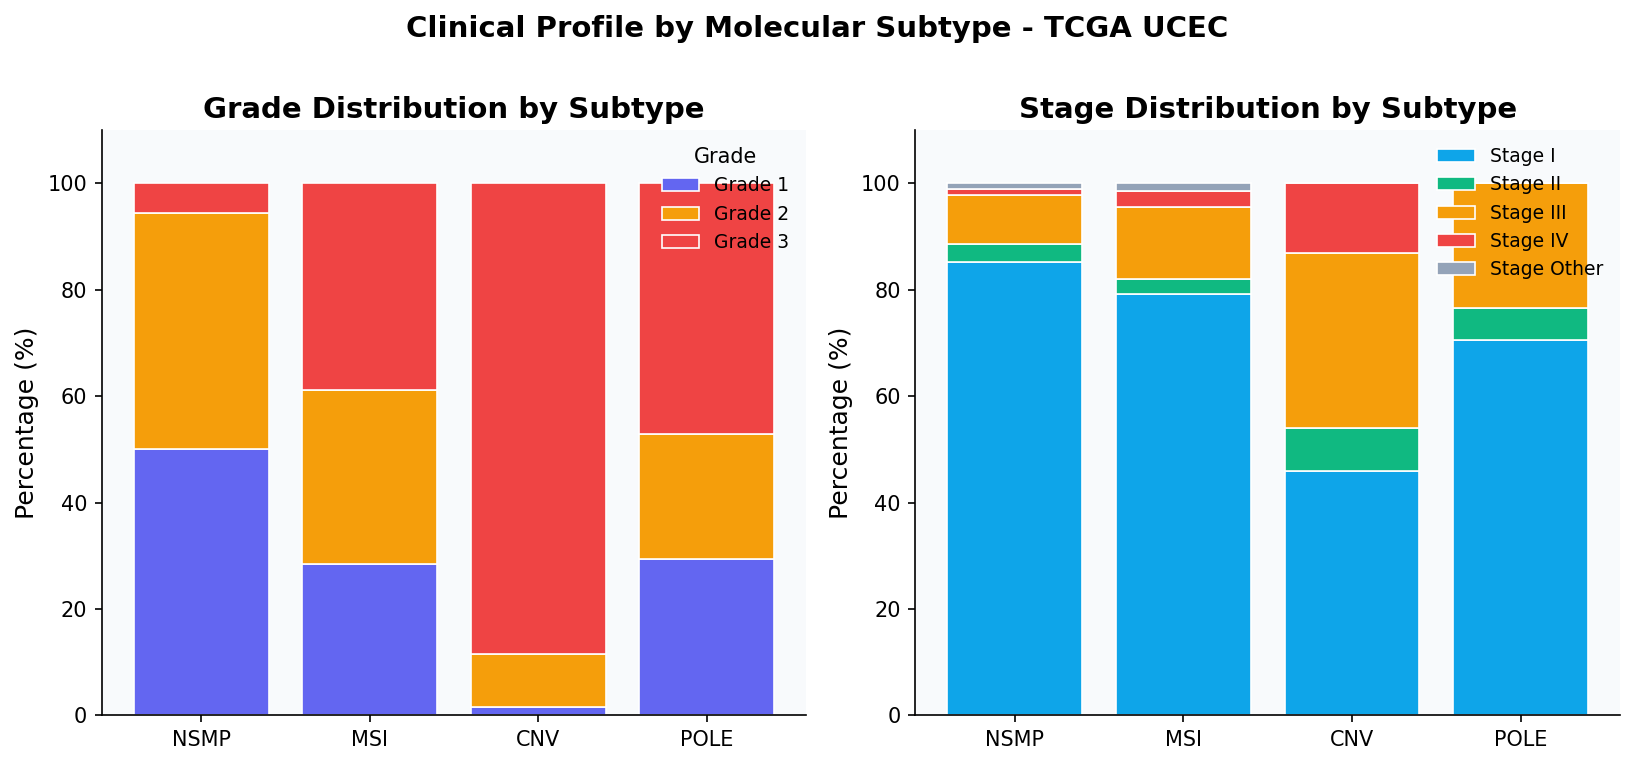

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))   # 2 panels, not 3

# Panel 1: Grade 
ax = axes[0]
grade_col = next((c for c in ['grade','tumor_grade','histology_grade']
                  if c in meta_lab.columns), None)
if grade_col:
    gs = meta_lab[['subtype_clean', grade_col]].dropna()
    gc = gs.groupby(['subtype_clean', grade_col]).size().unstack(fill_value=0)
    gp = gc.div(gc.sum(axis=1), axis=0) * 100
    gp = gp.reindex(SUBTYPE_ORDER).fillna(0)
    grade_colors = ['#6366F1','#F59E0B','#EF4444','#94A3B8','#10B981']
    bottom = np.zeros(len(SUBTYPE_ORDER))
    for i, grade in enumerate(gp.columns):
        ax.bar(SUBTYPE_ORDER, gp[grade].values, bottom=bottom,
               color=grade_colors[i % len(grade_colors)],
               label=str(grade), edgecolor='white', linewidth=0.8)
        bottom += gp[grade].fillna(0).values
    ax.set_ylim(0, 110)
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Grade Distribution by Subtype', fontweight='bold')
    ax.legend(frameon=False, title='Grade', loc='upper right', fontsize=9)
    ax.set_facecolor('#F8FAFC')

# Panel 2: Stage 
ax2 = axes[1]
stage_col = next((c for c in ['stage','X2009stagegroup','ajcc_pathologic_stage','tumor_stage']
                  if c in meta_lab.columns), None)
if stage_col:
    ss = meta_lab[['subtype_clean', stage_col]].dropna().copy()
    def simplify_stage(s):
        s = str(s).upper()
        for stg in ['IV','III','II','I']:
            if stg in s: return stg
        return 'Other'
    ss['stage_simple'] = ss[stage_col].apply(simplify_stage)
    sc = ss.groupby(['subtype_clean','stage_simple']).size().unstack(fill_value=0)
    sp = sc.div(sc.sum(axis=1), axis=0) * 100
    sp = sp.reindex(SUBTYPE_ORDER).fillna(0)
    stage_cols = {'I':'#0EA5E9','II':'#10B981','III':'#F59E0B',
                  'IV':'#EF4444','Other':'#94A3B8'}
    bottom = np.zeros(len(SUBTYPE_ORDER))
    for stg in ['I','II','III','IV','Other']:
        if stg in sp.columns:
            ax2.bar(SUBTYPE_ORDER, sp[stg].values, bottom=bottom,
                    color=stage_cols[stg], label=f'Stage {stg}',
                    edgecolor='white', linewidth=0.8)
            bottom += sp[stg].fillna(0).values
    ax2.set_ylim(0, 110)
    ax2.set_ylabel('Percentage (%)')
    ax2.set_title('Stage Distribution by Subtype', fontweight='bold')
    ax2.legend(frameon=False, loc='upper right', fontsize=9)
    ax2.set_facecolor('#F8FAFC')

plt.suptitle('Clinical Profile by Molecular Subtype - TCGA UCEC',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
savefig('clinical_profile.png')

## 9. Marker Gene Expression

In [18]:
MARKER_GENES = {
    'POLE (DNA repair)':   ['POLE','POLD1','POLE2'],
    'MMR (MSI markers)':   ['MLH1','MSH2','MSH6','PMS2'],
    'TP53 pathway (CNV)':  ['TP53','CDKN2A','MDM2'],
    'Immune (checkpoint)': ['PDCD1','CD274','CTLA4','CD8A'],
}

sym_col = next((c for c in gene_meta.columns
                if 'name' in c.lower() or 'symbol' in c.lower()
                or c.lower() == 'gene_name'), None)
if sym_col:
    sym2ens  = gene_meta[sym_col].dropna()
    ens2sym  = {ens: sym for ens, sym in sym2ens.items()}
    sym2ens_dict = {sym: ens for ens, sym in ens2sym.items()}
    all_markers  = [g for grp in MARKER_GENES.values() for g in grp]
    found_ens    = [sym2ens_dict[g] for g in all_markers
                    if g in sym2ens_dict and sym2ens_dict[g] in log2tpm.columns]
    print(f'Marker genes found: {len(found_ens)}/{len(all_markers)}')
    print('Found:', [ens2sym.get(e, e) for e in found_ens])
else:
    found_ens    = []
    sym2ens_dict = {}
    ens2sym      = {}
    print('WARNING: gene_name column not found - skipping marker plots')


Marker genes found: 14/14
Found: ['POLE', 'POLD1', 'POLE2', 'MLH1', 'MSH2', 'MSH6', 'PMS2', 'TP53', 'CDKN2A', 'MDM2', 'PDCD1', 'CD274', 'CTLA4', 'CD8A']


Saved: ../results/figures/marker_gene_violins.png


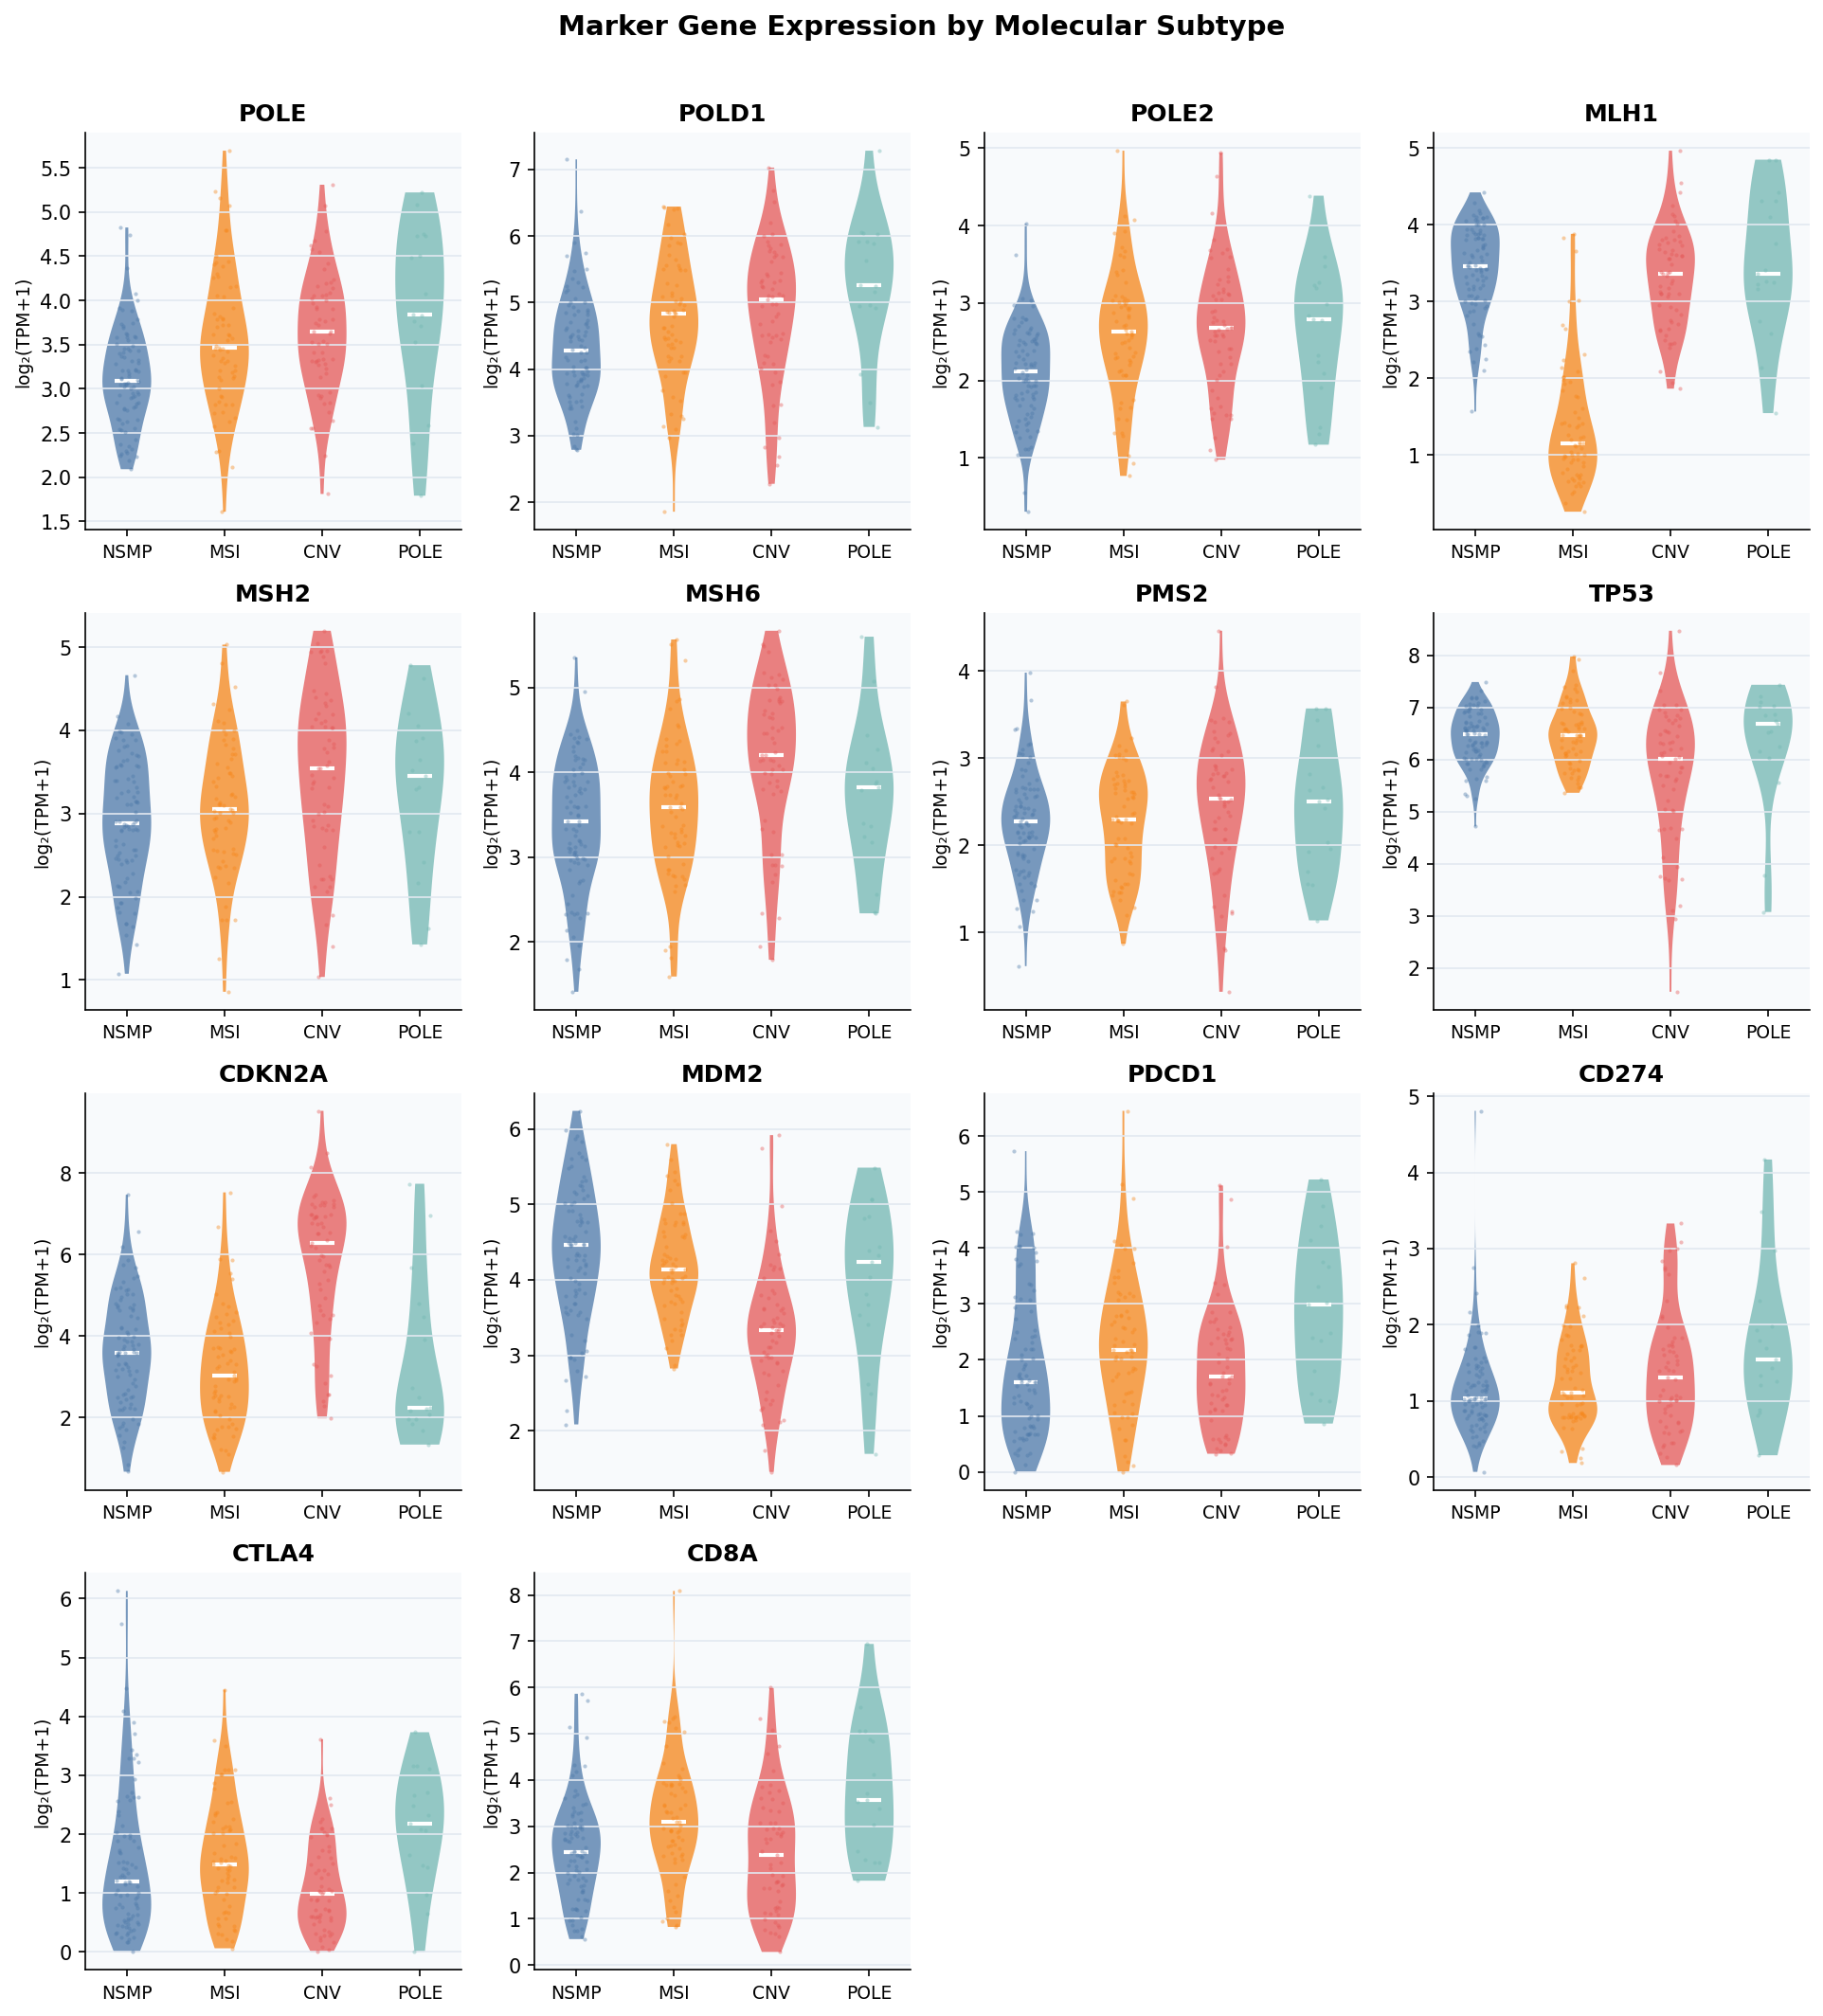

In [19]:
if sym2ens_dict and found_ens:
    ncols = 4
    nrows = int(np.ceil(len(found_ens) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.5))
    axes = axes.flatten()
    for i, ens in enumerate(found_ens):
        sym = ens2sym.get(ens, ens)
        ax  = axes[i]
        plot_data = [log2tpm.loc[meta_lab['subtype_clean'] == st, ens].dropna().values
                     for st in SUBTYPE_ORDER]
        parts = ax.violinplot(plot_data, positions=range(len(SUBTYPE_ORDER)),
                               showmedians=True, showextrema=False)
        for j, pc in enumerate(parts['bodies']):
            pc.set_facecolor(SUBTYPE_COLORS[j]); pc.set_alpha(0.75)
        parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
        for j, vals in enumerate(plot_data):
            jitter = np.random.uniform(-0.12, 0.12, len(vals))
            ax.scatter(j + jitter, vals, s=4, alpha=0.4,
                       color=SUBTYPE_COLORS[j], linewidths=0, zorder=3)
        ax.set_xticks(range(len(SUBTYPE_ORDER)))
        ax.set_xticklabels(SUBTYPE_ORDER, fontsize=9)
        ax.set_ylabel('log₂(TPM+1)', fontsize=9)
        ax.set_title(sym, fontsize=12, fontweight='bold')
        ax.set_facecolor('#F8FAFC'); ax.yaxis.grid(True, color='#E2E8F0', zorder=0)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Marker Gene Expression by Molecular Subtype',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    savefig('marker_gene_violins.png')
else:
    print('Skipping marker gene plot.')


## 10. Tumour Mutation Burden (TMB)

In [20]:
# Reading MAF by exact column position (bypasses CSV parsing corruption)
print('Reading somatic mutation file...\n')
with open(f'{DATA_DIR}/ucec_somatic_mutations.csv', 'r') as f:
    header = f.readline().strip().split(',')

tsb_idx = header.index('Tumor_Sample_Barcode')
sym_idx = header.index('Hugo_Symbol')
vc_idx  = header.index('Variant_Classification')
print(f'Column positions - Hugo={sym_idx}, TSB={tsb_idx}, VC={vc_idx}')

records = []
with open(f'{DATA_DIR}/ucec_somatic_mutations.csv', 'r') as f:
    f.readline()
    for line in f:
        fields = line.split(',')
        if len(fields) <= tsb_idx:
            continue
        try:
            records.append({
                'Hugo_Symbol':            fields[sym_idx],
                'Tumor_Sample_Barcode':   fields[tsb_idx],
                'Variant_Classification': fields[vc_idx],
            })
        except IndexError:
            continue

maf_clean = pd.DataFrame(records)
print(f'Rows parsed: {len(maf_clean):,}')
print(f'\nVariant classes:\n{maf_clean["Variant_Classification"].value_counts().head(6)}')


Reading somatic mutation file...

Column positions - Hugo=0, TSB=15, VC=8
Rows parsed: 626,945

Variant classes:
Variant_Classification
Missense_Mutation    395982
Silent               139101
Nonsense_Mutation     37317
Frame_Shift_Del       19358
Splice_Site            8652
Frame_Shift_Ins        6665
Name: count, dtype: int64


In [21]:
# Computing TMB per patient
maf_clean['patient_12'] = maf_clean['Tumor_Sample_Barcode'].str[:12]

patient_mut = (maf_clean.groupby('patient_12').size()
               .reset_index(name='n_mutations'))
patient_mut['TMB'] = patient_mut['n_mutations'] / 30.0   # mut per Mb

sub_for_tmb = subtypes[['subtype_clean']].copy()
sub_for_tmb.index = sub_for_tmb.index.str[:12]
sub_for_tmb = sub_for_tmb.reset_index()
sub_for_tmb.columns = ['patient_12', 'subtype_clean']

tmb_df = patient_mut.merge(sub_for_tmb, on='patient_12', how='left')
tmb_df = tmb_df.dropna(subset=['subtype_clean'])

print(f'Samples with TMB + subtype: {len(tmb_df)}')
print('\nMedian TMB by subtype:')
print(tmb_df.groupby('subtype_clean')['TMB']
            .median().reindex(SUBTYPE_ORDER).round(1))


Samples with TMB + subtype: 224

Median TMB by subtype:
subtype_clean
NSMP      1.8
MSI      17.4
CNV       1.9
POLE    287.7
Name: TMB, dtype: float64


Saved: ../results/figures/tmb_by_subtype.png


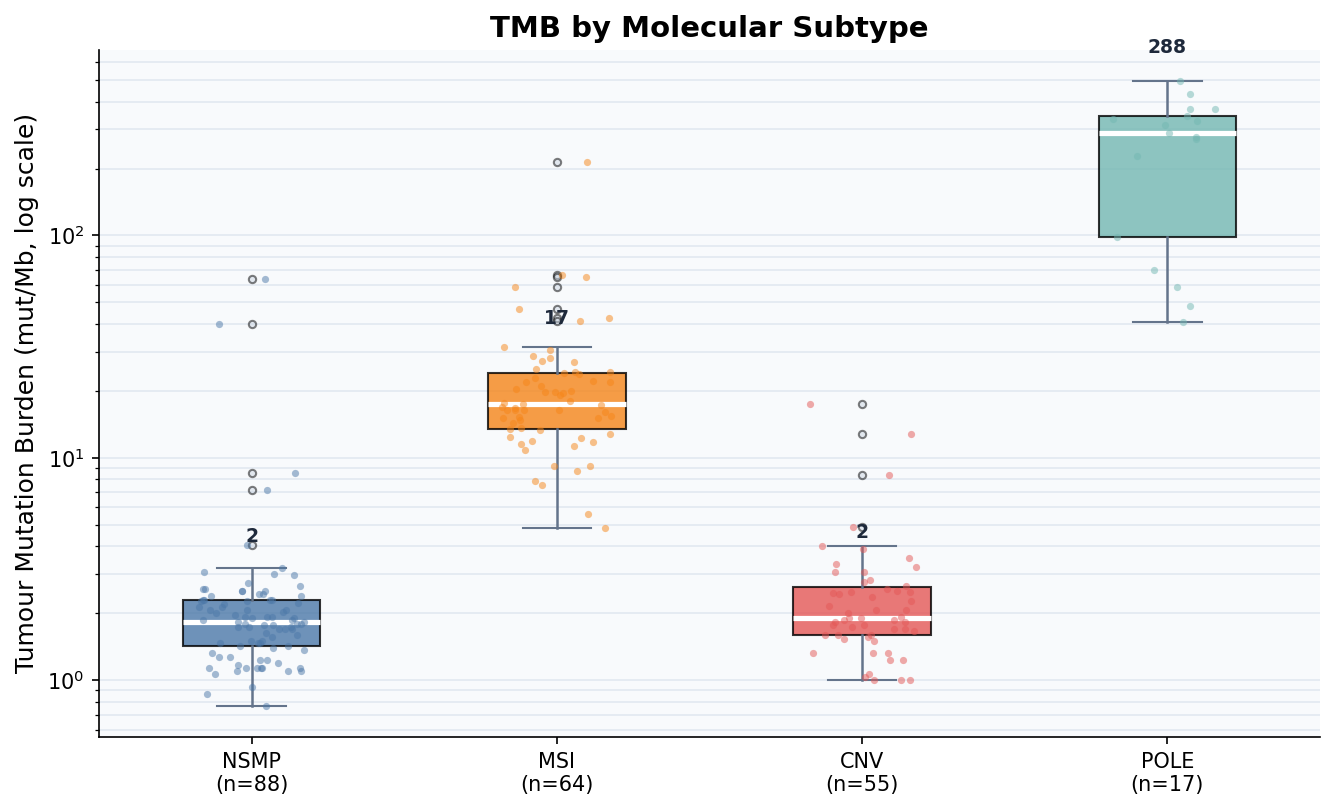

In [22]:
fig, ax = plt.subplots(figsize=(9, 5.5))

tmb_by_sub = [tmb_df.loc[(tmb_df['subtype_clean'] == st) & (tmb_df['TMB'] > 0), 'TMB'].values
              for st in SUBTYPE_ORDER]
valid_mask   = [len(v) > 0 for v in tmb_by_sub]
valid_order  = [st for st, ok in zip(SUBTYPE_ORDER,  valid_mask) if ok]
valid_vals   = [v  for v,  ok in zip(tmb_by_sub,     valid_mask) if ok]
valid_colors = [SUBTYPE_COLORS[SUBTYPE_ORDER.index(st)] for st in valid_order]

bp = ax.boxplot(valid_vals, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(color='#64748B', linewidth=1.2),
                capprops=dict(color='#64748B'),
                flierprops=dict(marker='o', markerfacecolor='#CBD5E1',
                               markersize=3.5, alpha=0.5))
for patch, col in zip(bp['boxes'], valid_colors):
    patch.set_facecolor(col); patch.set_alpha(0.8)

for j, (st, vals, col) in enumerate(zip(valid_order, valid_vals, valid_colors), 1):
    jitter = np.random.uniform(-0.18, 0.18, len(vals))
    ax.scatter(j + jitter, vals, s=12, alpha=0.5, color=col, linewidths=0, zorder=3)

ax.set_yscale('log')
ax.set_xticks(range(1, len(valid_order) + 1))
ax.set_xticklabels([f'{st}\n(n={len(v)})' for st, v in zip(valid_order, valid_vals)])
ax.set_ylabel('Tumour Mutation Burden (mut/Mb, log scale)')
ax.set_title('TMB by Molecular Subtype',
             fontweight='bold')
ax.set_facecolor('#F8FAFC')
ax.yaxis.grid(True, color='#E2E8F0', zorder=0, which='both')
for j, vals in enumerate(valid_vals, 1):
    med = np.median(vals)
    ax.text(j, med * 2.2, f'{med:.0f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#1E293B')
plt.tight_layout()
savefig('tmb_by_subtype.png')


POLE has 160x higher TMB when compared to NSMP

## 11. Kaplan-Meier Survival Curves


In [23]:
surv = meta_lab[['subtype_clean','os_days_num','event']].copy()
surv = surv.rename(columns={'os_days_num':'os_days'})
surv = surv.dropna()
surv = surv[surv['os_days'] > 0]
surv['os_years'] = surv['os_days'] / 365.25

print(f'Samples with survival data: {len(surv)}')
print(surv.groupby('subtype_clean')[['event','os_years']].agg(
    {'event':'sum','os_years':'median'}).reindex(SUBTYPE_ORDER))

results = multivariate_logrank_test(
    surv['os_days'], surv['subtype_clean'], surv['event'])
print(f'\nLog-rank p-value: {results.p_value:.2e}')


Samples with survival data: 233
               event  os_years
subtype_clean                 
NSMP             4.0  2.313484
MSI              7.0  2.280630
CNV             10.0  2.083504
POLE             0.0  2.746064

Log-rank p-value: 7.07e-02


Saved: ../results/figures/km_overall_survival.png


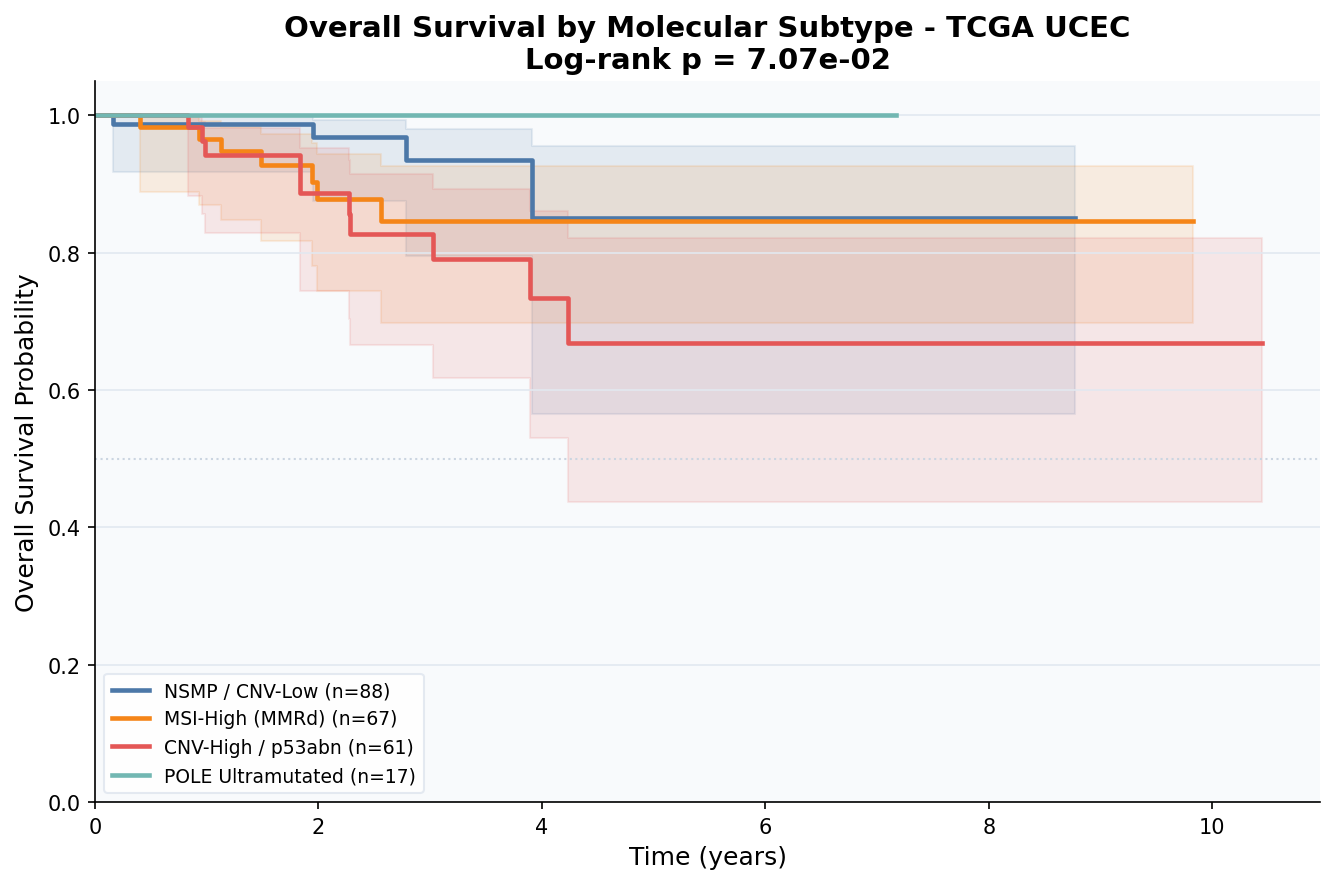

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
kmf = KaplanMeierFitter()

for st, col in zip(SUBTYPE_ORDER, SUBTYPE_COLORS):
    mask = surv['subtype_clean'] == st
    if mask.sum() == 0:
        continue
    kmf.fit(surv.loc[mask, 'os_years'], surv.loc[mask, 'event'],
            label=f'{full_labels[st]} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, color=col, linewidth=2.2,
                               ci_show=True, ci_alpha=0.12)

ax.set_xlabel('Time (years)')
ax.set_ylabel('Overall Survival Probability')
ax.set_title(f'Overall Survival by Molecular Subtype - TCGA UCEC\nLog-rank p = {results.p_value:.2e}',
             fontweight='bold')
ax.set_xlim(left=0); ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='#CBD5E1', ls=':', lw=1)
ax.set_facecolor('#F8FAFC'); ax.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax.legend(frameon=True, framealpha=0.92, edgecolor='#E2E8F0', fontsize=9)
plt.tight_layout()
savefig('km_overall_survival.png')


**Why is the p-value 0.07?**

The test is correct, the curves are in the right biological direction, but the dataset doesn't have enough death events to reach statistical significance. This is a limitation of the data, not the analysis.

## 12. XGBoost Subtype Classifier

In [25]:
# Restoring barcode index and removing duplicates
# The KM survival merge may have reset meta_lab index to integers - restoring that

if not isinstance(meta_lab.index[0], str):
    print('Restoring barcode index...')
    barcode_map = pd.DataFrame({
        'sample_barcode': tpm_raw.columns.tolist(),
        'patient_12':     [s[:12] for s in tpm_raw.columns]
    })
    meta_lab = meta_lab.reset_index(drop=True)
    meta_lab = meta_lab.merge(barcode_map, on='patient_12', how='left')
    meta_lab = meta_lab.set_index('sample_barcode')

# Deduplicate (keep first aliquot per patient)
meta_lab = meta_lab[~meta_lab.index.duplicated(keep='first')]
print(f'Samples after dedup: {meta_lab.shape[0]}')
print(meta_lab['subtype_clean'].value_counts())


Samples after dedup: 233
subtype_clean
NSMP    88
MSI     67
CNV     61
POLE    17
Name: count, dtype: int64


In [26]:
# Building X and y
tpm_mat_xgb = tpm_raw.T.loc[meta_lab.index]
log2tpm_xgb = np.log2(tpm_mat_xgb + 1)
gm          = (log2tpm_xgb > 0).mean(axis=0) >= 0.20
lf          = log2tpm_xgb.loc[:, gm]
hvg         = lf.std(axis=0).nlargest(3000).index

X     = lf[hvg].values
y_raw = meta_lab['subtype_clean'].values

le = LabelEncoder()
y  = le.fit_transform(y_raw)
print('Classes:       ', le.classes_)
print('X shape:       ', X.shape)
print('y distribution:', dict(zip(*np.unique(y_raw, return_counts=True))))

# Sample weights for class imbalance
counts_cls     = Counter(y_raw)
majority       = max(counts_cls.values())
weights        = {le.transform([cls])[0]: majority / cnt
                  for cls, cnt in counts_cls.items()}
sample_weights = np.array([weights[yi] for yi in y])
print('\nClass weights:', {le.classes_[k]: round(v, 2) for k, v in weights.items()})


Classes:        ['CNV' 'MSI' 'NSMP' 'POLE']
X shape:        (233, 3000)
y distribution: {'CNV': np.int64(61), 'MSI': np.int64(67), 'NSMP': np.int64(88), 'POLE': np.int64(17)}

Class weights: {'NSMP': 1.0, 'CNV': 1.44, 'MSI': 1.31, 'POLE': 5.18}


In [27]:
# 5-fold cross-validation
model_cv = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.3,
    eval_metric='mlogloss', random_state=42, n_jobs=-1,
)

cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred       = np.zeros(len(y), dtype=int)
y_pred_proba = np.zeros((len(y), len(le.classes_)))

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    model_cv.fit(X[train_idx], y[train_idx],
                 sample_weight=sample_weights[train_idx])
    y_pred[test_idx]          = model_cv.predict(X[test_idx])
    y_pred_proba[test_idx, :] = model_cv.predict_proba(X[test_idx])
    print(f'  Fold {fold+1}/5 done')

print('\n===CROSS-VALIDATION RESULTS===')
print(classification_report(y, y_pred, target_names=le.classes_))

auc = roc_auc_score(y, y_pred_proba, multi_class='ovr', average='macro')
print(f'Macro ROC-AUC (OvR): {auc:.3f}')


  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

===CROSS-VALIDATION RESULTS===
              precision    recall  f1-score   support

         CNV       0.87      0.97      0.91        61
         MSI       0.87      0.90      0.88        67
        NSMP       0.90      0.90      0.90        88
        POLE       0.50      0.24      0.32        17

    accuracy                           0.87       233
   macro avg       0.78      0.75      0.75       233
weighted avg       0.85      0.87      0.86       233

Macro ROC-AUC (OvR): 0.948


Saved: ../results/figures/confusion_matrix.png


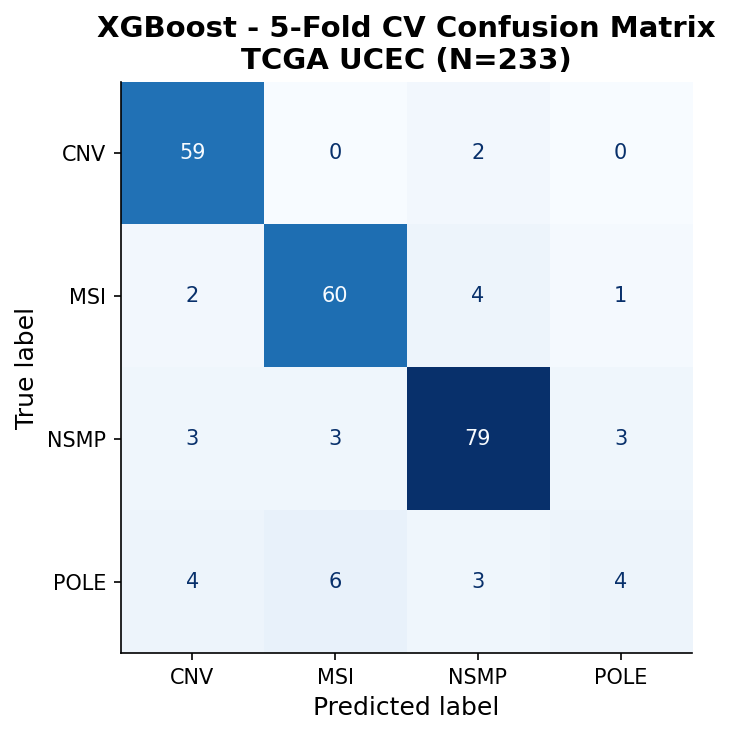

In [28]:
# Confusion matrix
cm  = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('XGBoost - 5-Fold CV Confusion Matrix\nTCGA UCEC (N=233)',
             fontweight='bold')
plt.tight_layout()
savefig('confusion_matrix.png')


## 13. Summary Verification Report

In [29]:
print('===TCGA UCEC - PIPELINE SUMMARY===')
print(f'\n--- GENES ---')
print(f'Total genes in raw matrix:     {counts_raw.shape[0]:>8,}')
print(f'Expressed in ≥20% samples:     {gene_mask.sum():>8,}')
print(f'HVGs used for modeling:        {len(top3000):>8,}')
if 'gene_type' in gene_meta.columns:
    pc = (gene_meta['gene_type'] == 'protein_coding').sum()
    print(f'Protein-coding genes:          {pc:>8,}')

print(f'\n--- SAMPLES ---')
print(f'Total RNA-seq samples:         {counts_raw.shape[1]:>8,}')
print(f'Labeled samples (4 subtypes):  {meta_lab.shape[0]:>8,}')
print(f'Survival data available:       {len(surv):>8,}')

print(f'\n--- SUBTYPE BREAKDOWN ---')
for st in SUBTYPE_ORDER:
    n   = (meta_lab['subtype_clean'] == st).sum()
    pct = n / len(meta_lab) * 100
    print(f'{st:<10}  {n:>4}  ({pct:.1f}%)')

print(f'\n--- PCA ---')
print(f'PC1: {ev[0]:.1f}%  PC2: {ev[1]:.1f}%')
if 'n80' in dir(): print(f'PCs for 80% variance: {n80}   PCs for 90%: {n90}')

print(f'\n--- TMB VALIDATION ---')
for st in SUBTYPE_ORDER:
    m = tmb_df.loc[tmb_df['subtype_clean'] == st, 'TMB'].median()
    print(f'{st:<10}  median TMB = {m:.1f} mut/Mb')

print(f'\nPipeline complete!')



===TCGA UCEC - PIPELINE SUMMARY===

--- GENES ---
Total genes in raw matrix:       60,660
Expressed in ≥20% samples:       37,646
HVGs used for modeling:           3,000
Protein-coding genes:            19,962

--- SAMPLES ---
Total RNA-seq samples:              553
Labeled samples (4 subtypes):       233
Survival data available:            233

--- SUBTYPE BREAKDOWN ---
NSMP          88  (37.8%)
MSI           67  (28.8%)
CNV           61  (26.2%)
POLE          17  (7.3%)

--- PCA ---
PC1: 10.4%  PC2: 7.5%
PCs for 80% variance: 51   PCs for 90%: 51

--- TMB VALIDATION ---
NSMP        median TMB = 1.8 mut/Mb
MSI         median TMB = 17.4 mut/Mb
CNV         median TMB = 1.9 mut/Mb
POLE        median TMB = 287.7 mut/Mb

Pipeline complete!


## 14. Saving Processed Files

In [30]:
PROC_DIR = '../data/processed/TCGA_UCEC_processed'
os.makedirs(PROC_DIR, exist_ok=True)

log2tpm[top3000].to_csv(f'{PROC_DIR}/X_log2tpm_hvg3000.csv')
log2tpm.to_csv(f'{PROC_DIR}/X_log2tpm_filtered.csv')
meta_lab[['subtype_clean']].to_csv(f'{PROC_DIR}/y_subtypes.csv')
meta_lab.to_csv(f'{PROC_DIR}/clinical_aligned.csv')
pca_df.to_csv(f'{PROC_DIR}/pca_coords.csv')

print('Saved:')
for f in os.listdir(PROC_DIR):
    size = os.path.getsize(f'{PROC_DIR}/{f}') / 1e6
    print(f'{f:<35} {size:.1f} MB')


Saved:
pca_coords.csv                      0.0 MB
clinical_aligned.csv                0.0 MB
X_log2tpm_filtered.csv              135.0 MB
X_log2tpm_hvg3000.csv               12.3 MB
y_subtypes.csv                      0.0 MB


## Stage 4: SHAP - Figures with Gene Symbols

In [31]:
# Regenerate SHAP top-50 CSVs from scratch 

PROC_DIR = '../data/processed/TCGA_UCEC_processed'
SHAP_DIR = '../results/shap_results'
os.makedirs(SHAP_DIR, exist_ok=True)

# Load data
X_df  = pd.read_csv(f'{PROC_DIR}/X_log2tpm_hvg3000.csv', index_col=0)
y_df  = pd.read_csv(f'{PROC_DIR}/y_subtypes.csv', index_col=0)

common_idx = X_df.index.intersection(y_df.index)
X_df       = X_df.loc[common_idx]
y_df       = y_df.loc[common_idx]

X          = X_df.values
y_raw      = y_df['subtype_clean'].values
gene_names = X_df.columns.tolist()

le = LabelEncoder()
y  = le.fit_transform(y_raw)
print(f'X: {X.shape}  |  Classes: {le.classes_}')

# Class weights
counts_cls     = Counter(y_raw)
majority       = max(counts_cls.values())
weights        = {le.transform([c])[0]: majority / n for c, n in counts_cls.items()}
sample_weights = np.array([weights[yi] for yi in y])

# Fit XGBoost on full dataset
print('Fitting XGBoost...')
model_full = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.3,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
model_full.fit(X, y, sample_weight=sample_weights)
print('Done!')

# Computing SHAP values
print('\nComputing SHAP values...')
explainer   = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(X)
sv = np.array(shap_values)
print(f'Raw SHAP shape: {sv.shape}')

# Reshape to (n_classes, n_samples, n_features)
if sv.ndim == 3:
    if sv.shape == (len(X), len(gene_names), len(le.classes_)):
        sv = sv.transpose(2, 0, 1)   # (samples, genes, classes) -> (classes, samples, genes)
    elif sv.shape == (len(le.classes_), len(X), len(gene_names)):
        pass                          # already correct
print(f'Reshaped SHAP: {sv.shape}')  # should be (4, 233, 3000)

# Extracting top 50 genes per subtype and save
top_shap_genes = {}
for i, cls_name in enumerate(le.classes_):
    class_shap = sv[i]                     # (233, 3000)
    mean_abs   = pd.Series(np.abs(class_shap).mean(axis=0), index=gene_names)
    top50      = mean_abs.nlargest(50)
    top_shap_genes[cls_name] = top50

    out = top50.reset_index()
    out.columns = ['gene_id', 'mean_abs_shap']
    out.to_csv(f'{SHAP_DIR}/shap_top50_{cls_name}.csv', index=False)
    print(f'{cls_name}: saved {len(top50)} genes, top gene = {top50.index[0]}')

# Also saving the sv array for later use (SHAP score computation)
np.save(f'{SHAP_DIR}/shap_values_array.npy', sv)
print(f'\nAll SHAP files saved to {SHAP_DIR}/')
print(f'Files: {os.listdir(SHAP_DIR)}')

X: (233, 3000)  |  Classes: ['CNV' 'MSI' 'NSMP' 'POLE']
Fitting XGBoost...
Done!

Computing SHAP values...
Raw SHAP shape: (233, 3000, 4)
Reshaped SHAP: (4, 233, 3000)
CNV: saved 50 genes, top gene = ENSG00000267466.1
MSI: saved 50 genes, top gene = ENSG00000076242.16
NSMP: saved 50 genes, top gene = ENSG00000076242.16
POLE: saved 50 genes, top gene = ENSG00000154451.14

All SHAP files saved to ../results/shap_results/
Files: ['shap_values_array.npy', 'shap_top50_NSMP.csv', 'shap_top50_MSI.csv', 'shap_top50_POLE.csv', 'shap_top50_CNV.csv']


In [32]:
# Loading gene metadata and build Ensembl -> symbol map 
DATA_DIR = '../data/raw/TCGA_UCEC_data'
gene_meta = pd.read_csv(f'{DATA_DIR}/ucec_gene_metadata.csv', index_col=0)

print('gene_meta columns:', gene_meta.columns.tolist()[:10])

# Auto-detecting symbol column
sym_col = next((c for c in gene_meta.columns
                if c.lower() in ['gene_name','symbol','gene_symbol',
                                  'name','external_gene_name']), None)
if sym_col is None:
    # Show all columns with samples so user can identify manually
    print('\nCould not auto-detect. Showing all columns:')
    for c in gene_meta.columns:
        sample = gene_meta[c].dropna().head(2).tolist()
        print(f'  {c}: {sample}')
    sym_col = gene_meta.columns[0]
    print(f'\nFalling back to first column: {sym_col}')

print(f'\nUsing symbol column: "{sym_col}"')
ens2sym = {}
for ens_id, sym in gene_meta[sym_col].dropna().items():
    # Store both with and without version number
    ens2sym[str(ens_id)] = str(sym)
    ens2sym[str(ens_id).split('.')[0]] = str(sym)

print(f'Mappable Ensembl IDs: {len(ens2sym):,}')
print('\nSample conversions:')
for ens in list(top_shap_genes['MSI'].head(3).index):
    base = ens.split('.')[0]
    sym  = ens2sym.get(ens, ens2sym.get(base, 'NOT FOUND'))
    print(f'{ens} -> {sym}')

gene_meta columns: ['source', 'type', 'score', 'phase', 'gene_id.1', 'gene_type', 'gene_name', 'level', 'hgnc_id', 'havana_gene']

Using symbol column: "gene_name"
Mappable Ensembl IDs: 121,276

Sample conversions:
ENSG00000076242.16 -> MLH1
ENSG00000178567.8 -> EPM2AIP1
ENSG00000163584.18 -> RPL22L1


In [33]:
# Converting Ensembl IDs to gene symbols for display 
def ens_to_display(ens_id, ens2sym, max_len=18):
    """Convert ENSG00000076242.16 -> MLH1, or shorten if not found."""
    # Strip version number
    base = ens_id.split('.')[0]
    sym  = ens2sym.get(base, ens2sym.get(ens_id, None))
    if sym:
        return sym[:max_len]
    # Shorten Ensembl ID for display
    return ens_id[:15] + '…'

# Test conversion
print('Key gene conversions:')
for ens in list(top_shap_genes['MSI'].head(5).index):
    print(f'{ens} -> {ens_to_display(ens, ens2sym)}')
print()
for ens in list(top_shap_genes['CNV'].head(5).index):
    print(f'{ens} -> {ens_to_display(ens, ens2sym)}')


Key gene conversions:
ENSG00000076242.16 -> MLH1
ENSG00000178567.8 -> EPM2AIP1
ENSG00000163584.18 -> RPL22L1
ENSG00000154760.14 -> SLFN13
ENSG00000272913.1 -> AC009237.14

ENSG00000267466.1 -> AC021683.1
ENSG00000141934.10 -> PLPP2
ENSG00000124762.14 -> CDKN1A
ENSG00000188959.9 -> C9orf152
ENSG00000107281.10 -> NPDC1



CNV top 10:
ENSG00000165698.16             -> SPACA9               SHAP=0.1180
ENSG00000169435.14             -> RASSF6               SHAP=0.1221
ENSG00000124664.11             -> SPDEF                SHAP=0.1386
ENSG00000095321.17             -> CRAT                 SHAP=0.1515
ENSG00000198910.14             -> L1CAM                SHAP=0.1638
ENSG00000107281.10             -> NPDC1                SHAP=0.1642
ENSG00000188959.9              -> C9orf152             SHAP=0.2134
ENSG00000124762.14             -> CDKN1A               SHAP=0.2135
ENSG00000141934.10             -> PLPP2                SHAP=0.3041
ENSG00000267466.1              -> AC021683.1           SHAP=0.3556

MSI top 10:
ENSG00000254615.3              -> AC027031.2           SHAP=0.0837
ENSG00000123405.14             -> NFE2                 SHAP=0.0869
ENSG00000162639.16             -> HENMT1               SHAP=0.0901
ENSG00000223298.1              -> RNY3P8               SHAP=0.0917
ENSG00000198553.9              -> KC

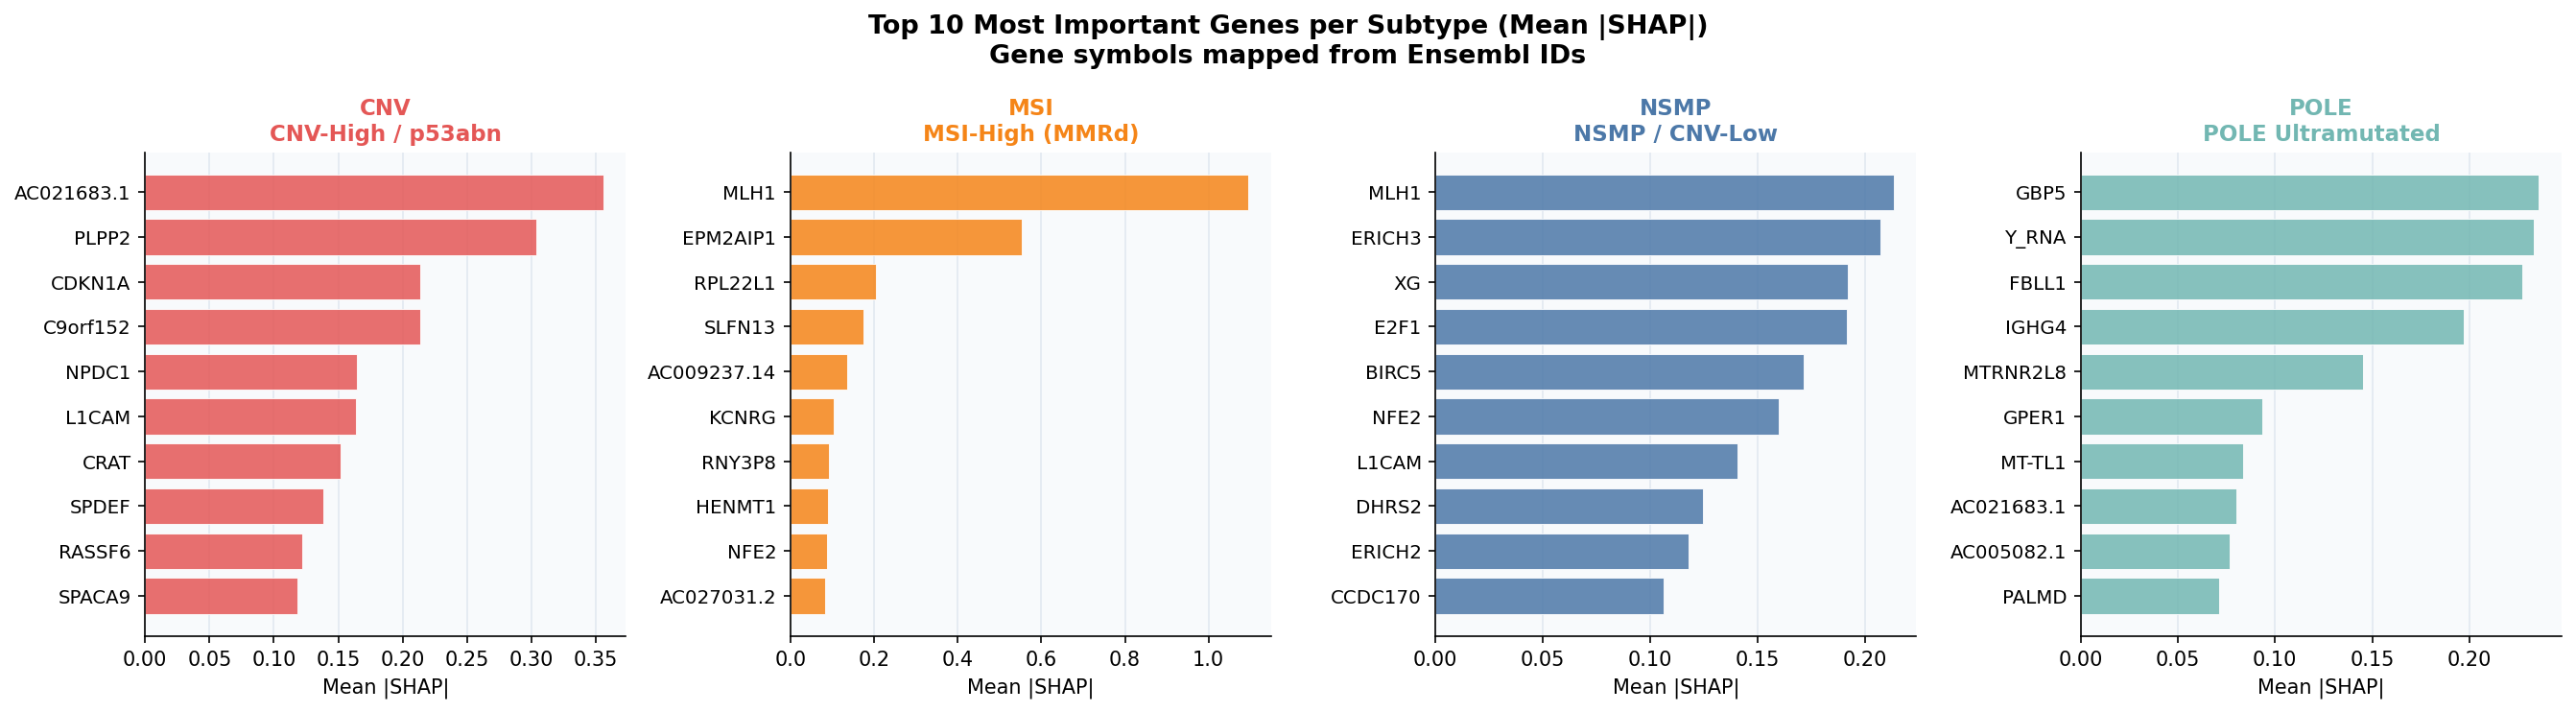

In [34]:
# Fig: SHAP bar chart with gene symbols 
colors_shap = {'NSMP':'#4C78A8','MSI':'#F58518','CNV':'#E45756','POLE':'#72B7B2'}
full_labels  = {'NSMP':'NSMP / CNV-Low','MSI':'MSI-High (MMRd)',
                'CNV':'CNV-High / p53abn','POLE':'POLE Ultramutated'}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, (cls_name, ax) in enumerate(zip(['CNV','MSI','NSMP','POLE'], axes)):
    top10  = top_shap_genes[cls_name].head(10)
    labels = [ens_to_display(e, ens2sym) for e in top10.index[::-1]]
    vals   = top10.values[::-1]

    ax.barh(range(len(top10)), vals,
            color=colors_shap[cls_name], alpha=0.85,
            edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(labels, fontsize=9.5)
    ax.set_xlabel('Mean |SHAP|', fontsize=10)
    ax.set_title(f'{cls_name}\n{full_labels[cls_name]}',
                 fontsize=11, fontweight='bold', color=colors_shap[cls_name])
    ax.set_facecolor('#F8FAFC')
    ax.xaxis.grid(True, color='#E2E8F0', zorder=0)
    ax.set_axisbelow(True)

    # Printing what labels resolved to (for verification)
    print(f'\n{cls_name} top 10:')
    for ens, lbl, val in zip(top10.index[::-1], labels, vals):
        print(f'{ens:30s} -> {lbl:<20s} SHAP={val:.4f}')

plt.suptitle('Top 10 Most Important Genes per Subtype (Mean |SHAP|)\nGene symbols mapped from Ensembl IDs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('shap_bar_symbols.png')


In [35]:
# Defining everything needed in this cell
colors_shap = {'CNV':'#EF4444','MSI':'#3B82F6','NSMP':'#F59E0B','POLE':'#10B981'}
full_labels  = {'NSMP':'NSMP / CNV-Low','MSI':'MSI-High (MMRd)',
                'CNV':'CNV-High / p53abn','POLE':'POLE Ultramutated'}

def is_valid_symbol(sym):
    """Filter out lncRNAs, pseudogenes, MT genes — keep standard protein-coding symbols."""
    if not sym or str(sym) == 'nan': return False
    sym = str(sym)
    if re.match(r'^(AC|AL|AP|BX|CR|CT|CU)\d+\.\d+$', sym): return False
    if re.match(r'^(LINC|MT-|RNY|MTRNR|SNORD|SNORA|MIR)\d*', sym): return False
    if sym.startswith('Y_RNA'): return False
    if re.match(r'^[A-Z]{2}\d{6}\.\d+$', sym): return False
    return True

# Diagnose
print('=== CLEAN SYMBOLS PER SUBTYPE ===')
for cls_name in le.classes_:
    ens_list  = top_shap_genes[cls_name].head(100).index.tolist()
    sym_list  = [ens2sym.get(e, ens2sym.get(e.split('.')[0], ''))
                 for e in ens_list]
    sym_clean = [s for s in sym_list if s and is_valid_symbol(s)][:50]
    print(f'\n{cls_name} ({len(sym_clean)} clean symbols):')
    print(' ', sym_clean)

# Running enrichment
print('\n=== ENRICHMENT ===')
enrichment_results = {}
GENE_SETS = ['KEGG_2021_Human','MSigDB_Hallmark_2020',
             'GO_Biological_Process_2021','WikiPathway_2023_Human']

for cls_name in le.classes_:
    ens_list  = top_shap_genes[cls_name].head(200).index.tolist()
    sym_list  = [ens2sym.get(e, ens2sym.get(e.split('.')[0], ''))
                 for e in ens_list]
    sym_clean = [s for s in sym_list if s and is_valid_symbol(s)][:100]

    if len(sym_clean) < 10:
        print(f'{cls_name}: not enough symbols, skipping')
        continue
    try:
        res = gp.enrichr(
            gene_list = sym_clean,
            gene_sets = GENE_SETS,
            organism  = 'human',
            cutoff    = 0.5,
            verbose   = False,
        )
        enrichment_results[cls_name] = res.results
        sig = res.results[res.results['Adjusted P-value'] < 0.1].sort_values('Adjusted P-value')
        print(f'\n{cls_name}: {len(sig)} significant pathways (adj p<0.1)')
        if len(sig) > 0:
            print(sig[['Gene_set','Term','Adjusted P-value','Overlap']].head(5).to_string(index=False))
    except Exception as e:
        print(f'{cls_name}: failed — {e}')

# Manual biological validation 
print('\n=== MANUAL BIOLOGICAL VALIDATION ===')
KNOWN_MARKERS = {
    'MMR / MSI':         ['MLH1','MSH2','MSH6','PMS2'],
    'POLE / DNA repair': ['POLE','POLD1','POLE2','MUTYH'],
    'p53 / cell cycle':  ['TP53','CDKN2A','MDM2','CDKN1A','CCND1','E2F1'],
    'Immune checkpoint': ['PDCD1','CD274','CTLA4','CD8A','GBP5'],
    'Proliferation':     ['BIRC5','MKI67','CCNB1','TOP2A','PCNA'],
    'EC driver genes':   ['PTEN','PIK3CA','ARID1A','CTNNB1','KRAS'],
    'Hormone receptors': ['ESR1','PGR','FOXA1','GPER1'],
}

for cls_name in le.classes_:
    ens_list  = top_shap_genes[cls_name].head(200).index.tolist()
    sym_list  = [ens2sym.get(e, ens2sym.get(e.split('.')[0], ''))
                 for e in ens_list]
    sym_set   = set(s for s in sym_list if s and is_valid_symbol(s))
    print(f'\n  {cls_name} — {full_labels[cls_name]}:')
    found_any = False
    for pathway, markers in KNOWN_MARKERS.items():
        hits = [m for m in markers if m in sym_set]
        if hits:
            print(f'{pathway:<25}: {hits}')
            found_any = True
    if not found_any:
        print('(No known markers found in top 200 genes)')

=== CLEAN SYMBOLS PER SUBTYPE ===

CNV (45 clean symbols):
  ['PLPP2', 'CDKN1A', 'C9orf152', 'NPDC1', 'L1CAM', 'CRAT', 'SPDEF', 'RASSF6', 'SPACA9', 'HIF3A', 'ANXA1', 'SFN', 'DUSP4', 'RSPO4', 'TTC9', 'DLGAP3', 'MX2', 'CCNE1', 'KLRG2', 'GALNT12', 'RNF212', 'NT5E', 'UCHL1', 'SMIM31', 'PCK1', 'FAM24B', 'LBP', 'ZFPM2-AS1', 'AK8', 'PALMD', 'PAX9', 'TFF3', 'MNX1', 'SST', 'NUPR2', 'ECEL1P1', 'CLDN9', 'ELAPOR1', 'MRAP2', 'ARHGAP29', 'MACROD2', 'ACTL8', 'BST2', 'FREM2', 'CTCFL']

MSI (44 clean symbols):
  ['MLH1', 'EPM2AIP1', 'RPL22L1', 'SLFN13', 'KCNRG', 'HENMT1', 'NFE2', 'C2CD4B', 'CHCHD5', 'H2AC20', 'HMGA1', 'ADGRL2', 'IGHV4-61', 'METTL27', 'FBLL1', 'DCAF12L1', 'NRGN', 'TP73', 'GALNT14', 'GAMT', 'BEX5', 'PTMAP4', 'TRBJ2-5', 'C1QL4', 'ZNF300', 'TIMP3', 'DEGS2', 'SULT4A1', 'HOXC11', 'CXCL1', 'ISG15', 'H2AJ', 'SYT7', 'HOXB-AS3', 'COL6A1', 'EPHB2', 'VAX2', 'HSD11B2', 'LAPTM4B', 'HOXC10', 'SUSD4', 'KRT19', 'HPDL', 'RIPPLY3']

NSMP (46 clean symbols):
  ['MLH1', 'ERICH3', 'XG', 'E2F1', 'BIRC5', 'NF

In [36]:
# Biological validation: known cancer genes in SHAP top lists
def is_valid_symbol(sym):
    if not sym or str(sym) == 'nan': return False
    sym = str(sym)
    if re.match(r'^(AC|AL|AP|BX|CR|CT|CU)\d+\.\d+$', sym): return False
    if re.match(r'^(LINC|MT-|RNY|MTRNR|SNORD|SNORA|MIR)\d*', sym): return False
    if sym.startswith('Y_RNA'): return False
    return True

full_labels = {'NSMP':'NSMP / CNV-Low','MSI':'MSI-High (MMRd)',
               'CNV':'CNV-High / p53abn','POLE':'POLE Ultramutated'}

KNOWN_MARKERS = {
    'MMR / MSI':         ['MLH1','MSH2','MSH6','PMS2','MLH3','EPCAM'],
    'POLE / DNA repair': ['POLE','POLD1','POLE2','POLE3','MUTYH'],
    'p53 / cell cycle':  ['TP53','CDKN2A','MDM2','RB1','CDKN1A','CCND1','E2F1'],
    'Immune checkpoint': ['PDCD1','CD274','CTLA4','CD8A','CD8B','GBP5','LAG3'],
    'Proliferation':     ['BIRC5','MKI67','CCNB1','CDC20','TOP2A','PCNA'],
    'EC driver genes':   ['PTEN','PIK3CA','PIK3R1','ARID1A','CTNNB1','KRAS','FGFR2'],
    'Hormone receptors': ['ESR1','PGR','FOXA1','AR','GPER1'],
    'EMT markers':       ['CDH1','VIM','ZEB1','SNAI1','L1CAM','FN1'],
}

print('===BIOLOGICAL VALIDATION — KNOWN MARKER GENES IN SHAP TOP-50===')

for cls_name in ['CNV','MSI','NSMP','POLE']:
    ens_list = top_shap_genes[cls_name].head(50).index.tolist()
    sym_list = [ens2sym.get(e.split('.')[0], ens2sym.get(e,'')) for e in ens_list]
    sym_set  = set(s for s in sym_list if s and is_valid_symbol(s))

    print(f'\n{cls_name} — {full_labels[cls_name]}:')
    found_any = False
    for pathway, markers in KNOWN_MARKERS.items():
        hits = [m for m in markers if m in sym_set]
        if hits:
            print(f'{pathway:<25}: {hits}')
            found_any = True
    if not found_any:
        print('(No standard markers in top 50)')

print("\n===========================================================")
print('\nInterpretation:')
print('MLH1 in MSI  -> model recovered canonical MMR gene')
print('CDKN1A in CNV -> model recovered p53 target gene')
print('GBP5 in POLE -> model recovered interferon immune gene')


===BIOLOGICAL VALIDATION — KNOWN MARKER GENES IN SHAP TOP-50===

CNV — CNV-High / p53abn:
p53 / cell cycle         : ['CDKN1A']
EMT markers              : ['L1CAM']

MSI — MSI-High (MMRd):
MMR / MSI                : ['MLH1']

NSMP — NSMP / CNV-Low:
MMR / MSI                : ['MLH1']
p53 / cell cycle         : ['E2F1']
Immune checkpoint        : ['LAG3']
Proliferation            : ['BIRC5', 'CDC20']
EMT markers              : ['L1CAM']

POLE — POLE Ultramutated:
Immune checkpoint        : ['GBP5', 'LAG3']
Hormone receptors        : ['GPER1']


Interpretation:
MLH1 in MSI  -> model recovered canonical MMR gene
CDKN1A in CNV -> model recovered p53 target gene
GBP5 in POLE -> model recovered interferon immune gene


## Stage 5: Survival Analysis


In [37]:
# Loading saved SHAP values (avoids refitting model)
PROC_DIR = '../data/processed/TCGA_UCEC_processed'
SHAP_DIR = '../results/shap_results'

# Load processed data
X_df  = pd.read_csv(f'{PROC_DIR}/X_log2tpm_hvg3000.csv', index_col=0)
y_df  = pd.read_csv(f'{PROC_DIR}/y_subtypes.csv',         index_col=0)
clin  = pd.read_csv(f'{PROC_DIR}/clinical_aligned.csv',   index_col=0)

common_idx = X_df.index.intersection(y_df.index).intersection(clin.index)
X_df  = X_df.loc[common_idx]
y_df  = y_df.loc[common_idx]
clin  = clin.loc[common_idx]

X          = X_df.values
y_raw      = y_df['subtype_clean'].values
gene_names = X_df.columns.tolist()

le = LabelEncoder()
le.fit(y_raw)
print(f'Classes: {le.classes_}')
print(f'Samples: {len(X_df)}')

# Load saved SHAP array 
shap_array_path = f'{SHAP_DIR}/shap_values_array.npy'

if os.path.exists(shap_array_path):
    sv = np.load(shap_array_path)
    print(f'Loaded saved SHAP array: {sv.shape}')
else:
    # Fallback: refit if array not saved
    print('SHAP array not found — refitting model (takes ~2 min)...')
    counts_cls     = Counter(y_raw)
    majority       = max(counts_cls.values())
    weights        = {le.transform([c])[0]: majority / n for c, n in counts_cls.items()}
    sample_weights = np.array([weights[le.transform([yi])[0]] for yi in y_raw])
    model_full = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.3,
                                eval_metric='mlogloss', random_state=42, n_jobs=-1)
    model_full.fit(X, le.transform(y_raw), sample_weight=sample_weights)
    explainer   = shap.TreeExplainer(model_full)
    shap_values = explainer.shap_values(X)
    sv = np.array(shap_values)
    if sv.ndim == 3 and sv.shape == (len(X), len(gene_names), len(le.classes_)):
        sv = sv.transpose(2, 0, 1)
    np.save(shap_array_path, sv)
    print(f'SHAP refitted and saved. Shape: {sv.shape}')

# Agnostic SHAP score = mean |SHAP| across all classes and genes per sample
shap_score_agnostic = np.abs(sv).mean(axis=(0, 2))
print(f'SHAP score computed. Shape: {shap_score_agnostic.shape}')
print(f'Range: {shap_score_agnostic.min():.4f} - {shap_score_agnostic.max():.4f}')


Classes: ['CNV' 'MSI' 'NSMP' 'POLE']
Samples: 233
Loaded saved SHAP array: (4, 233, 3000)
SHAP score computed. Shape: (233,)
Range: 0.0016 - 0.0019


In [38]:
# Building survival dataframe 
surv_df = clin[['subtype_clean','os_days_num','event','grade','stage',
                 'vital_status_true']].copy()
surv_df['shap_score'] = shap_score_agnostic
surv_df = surv_df.dropna(subset=['os_days_num','event'])
surv_df = surv_df[surv_df['os_days_num'] > 0]
surv_df['os_years'] = surv_df['os_days_num'] / 365.25

print(f'Survival samples: {len(surv_df)}')
print(f'Events (deaths):  {surv_df["event"].sum():.0f}')
print(f'SHAP score split:')
med = surv_df['shap_score'].median()
print(f'Median: {med:.4f}')
print(f'High group: {(surv_df["shap_score"] > med).sum()}')
print(f'Low group:  {(surv_df["shap_score"] <= med).sum()}')

Survival samples: 233
Events (deaths):  21
SHAP score split:
Median: 0.0017
High group: 116
Low group:  117


Saved: ../results/figures/km_shap_score_corrected.png


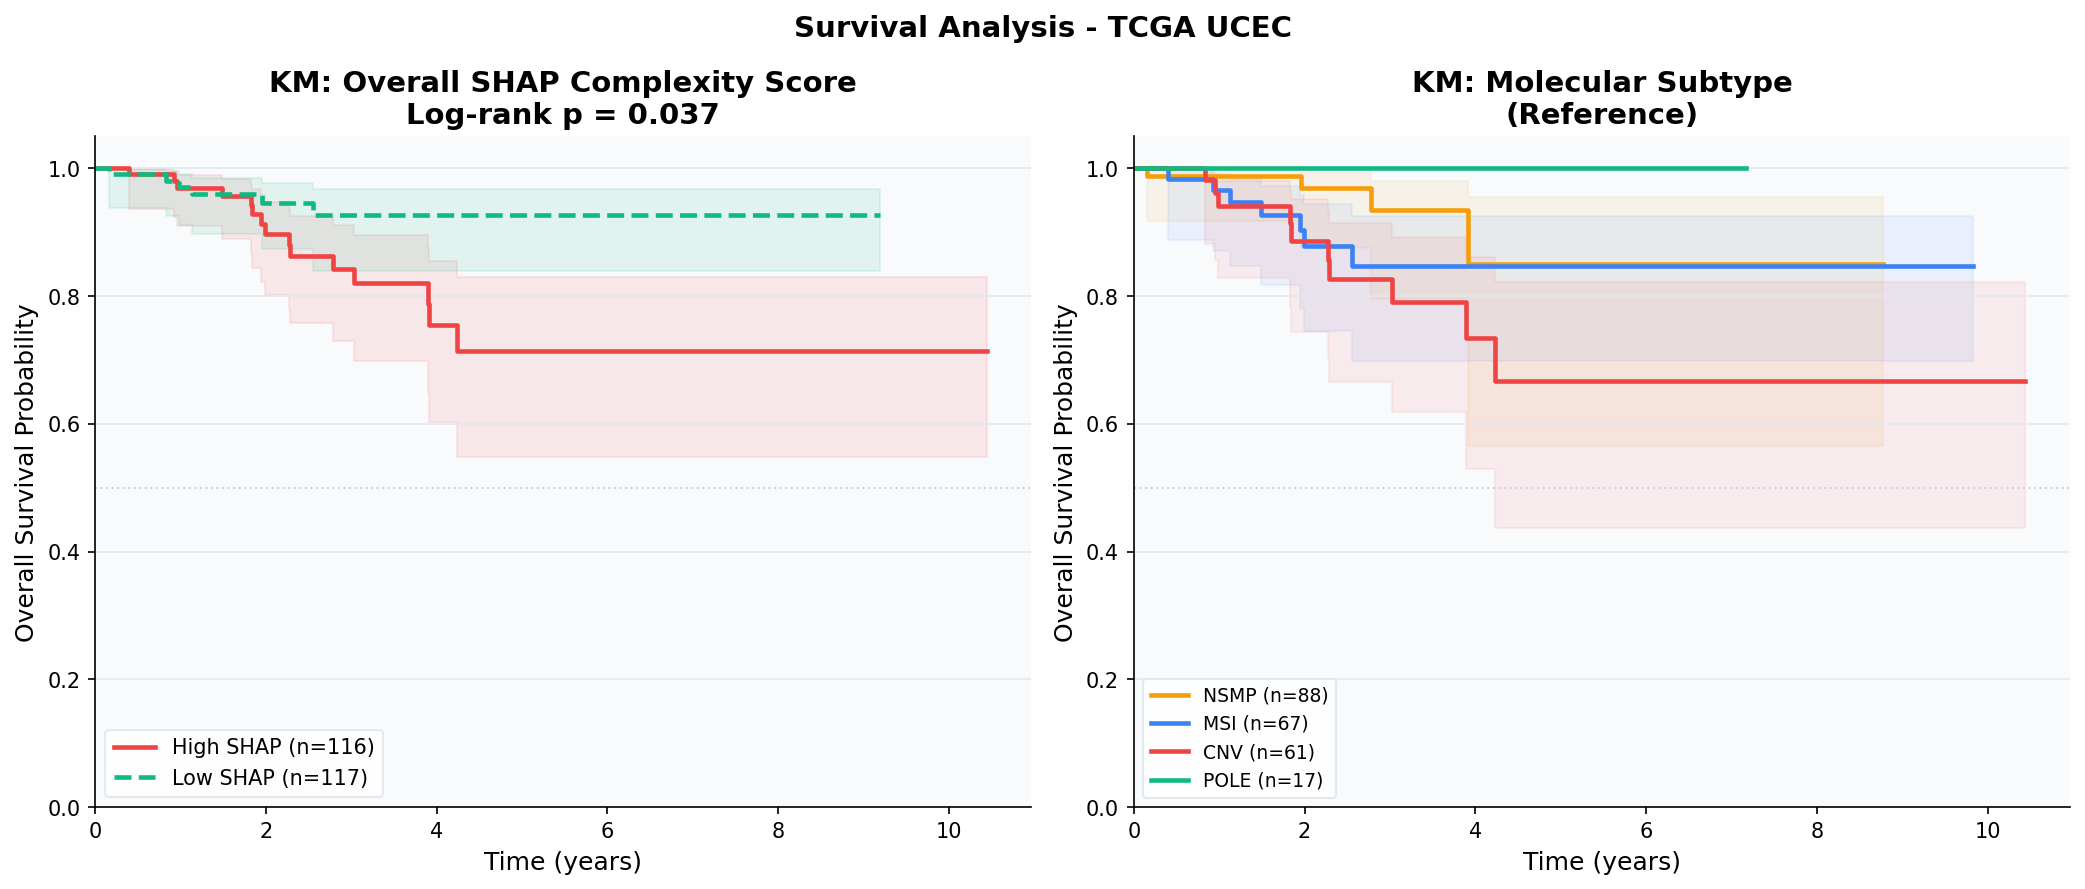

Log-rank p = 0.0370


In [39]:
# KM by SHAP score
median_shap = surv_df['shap_score'].median()
surv_df['shap_group'] = np.where(surv_df['shap_score'] > median_shap,
                                   'High SHAP', 'Low SHAP')

high_grp = surv_df[surv_df['shap_group'] == 'High SHAP']
low_grp  = surv_df[surv_df['shap_group'] == 'Low SHAP']

lr = logrank_test(high_grp['os_years'], low_grp['os_years'],
                  high_grp['event'],    low_grp['event'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: KM by SHAP
ax = axes[0]
kmf = KaplanMeierFitter()
for grp, col, ls in [('High SHAP','#EF4444','-'),('Low SHAP','#10B981','--')]:
    mask = surv_df['shap_group'] == grp
    kmf.fit(surv_df.loc[mask,'os_years'], surv_df.loc[mask,'event'],
            label=f'{grp} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, color=col, linestyle=ls, linewidth=2.2,
                               ci_show=True, ci_alpha=0.1)

ax.set_xlabel('Time (years)')
ax.set_ylabel('Overall Survival Probability')
ax.set_title(f'KM: Overall SHAP Complexity Score\nLog-rank p = {lr.p_value:.3f}',
             fontweight='bold')
ax.set_xlim(left=0); ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='#CBD5E1', ls=':', lw=1)
ax.set_facecolor('#F8FAFC'); ax.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax.legend(frameon=True, framealpha=0.92, edgecolor='#E2E8F0')

# Right: KM by subtype (reference)
ax2 = axes[1]
SUBTYPE_COLORS_KM = {'NSMP':'#F59E0B','MSI':'#3B82F6','CNV':'#EF4444','POLE':'#10B981'}
for st in SUBTYPE_ORDER:
    mask = surv_df['subtype_clean'] == st
    if mask.sum() < 3: continue
    kmf.fit(surv_df.loc[mask,'os_years'], surv_df.loc[mask,'event'],
            label=f'{st} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax2, color=SUBTYPE_COLORS_KM[st],
                               linewidth=2.2, ci_show=True, ci_alpha=0.08)

ax2.set_xlabel('Time (years)')
ax2.set_ylabel('Overall Survival Probability')
ax2.set_title('KM: Molecular Subtype\n(Reference)', fontweight='bold')
ax2.set_xlim(left=0); ax2.set_ylim(0, 1.05)
ax2.axhline(0.5, color='#CBD5E1', ls=':', lw=1)
ax2.set_facecolor('#F8FAFC'); ax2.yaxis.grid(True, color='#E2E8F0', zorder=0)
ax2.legend(frameon=True, framealpha=0.92, edgecolor='#E2E8F0', fontsize=9)

plt.suptitle('Survival Analysis - TCGA UCEC', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('km_shap_score_corrected.png')
print(f'Log-rank p = {lr.p_value:.4f}')


In [40]:
# Multivariate Cox model 
def encode_grade(g):
    g = str(g).upper()
    if 'GR1' in g or 'GRADE 1' in g: return 1
    if 'GR2' in g or 'GRADE 2' in g: return 2
    return 3  # Grade 3, Serous → worst

def encode_stage(s):
    s = str(s).upper()
    for n, stg in [(4,'IV'),(3,'III'),(2,'II'),(1,'I')]:
        if stg in s: return n
    return np.nan

cox_df = surv_df[['os_years','event','shap_score',
                   'subtype_clean','grade','stage']].copy()
cox_df['grade_num']       = cox_df['grade'].apply(encode_grade)
cox_df['stage_num']       = cox_df['stage'].apply(encode_stage)
cox_df['is_MSI']          = (cox_df['subtype_clean'] == 'MSI').astype(float)
cox_df['is_CNV']          = (cox_df['subtype_clean'] == 'CNV').astype(float)
cox_df['is_POLE']         = (cox_df['subtype_clean'] == 'POLE').astype(float)
cox_df['shap_score_std']  = ((cox_df['shap_score'] - cox_df['shap_score'].mean()) /
                               cox_df['shap_score'].std())

cox_clean = cox_df[['os_years','event','shap_score_std',
                     'grade_num','stage_num',
                     'is_MSI','is_CNV','is_POLE']].dropna()

print(f'Cox model: {len(cox_clean)} samples, {cox_clean["event"].sum():.0f} events')

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_clean, duration_col='os_years', event_col='event')
cph.print_summary()


Cox model: 231 samples, 20 events


<lifelines.CoxPHFitter: fitted with 231 total observations, 211 right-censored observations>
             duration col = 'os_years'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 231
number of events observed = 20
   partial log-likelihood = -89.66
         time fit was run = 2026-07-15 02:09:11 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
shap_score_std  0.14      1.15      0.16           -0.17            0.45                0.84                1.57
grade_num       0.28      1.32      0.20           -0.11            0.66                0.89                1.94
stage_num       0.30      1.35      0.15            0.00            0.59                1.00                1.80
is_MSI          0.07      1.07      0.35           -0.62            0.77                0.54                2.15
is_CNV          0.25      1.28      0.36           -0.45            0.94                0.64                2.57
is_POLE        -0.48      0.62      0.66           -1.78            0.82                0.17                2.28

                cmp to     z    p  -log2(p)
covariate                                  
shap_score_std    0.00  0.88 0.38      1.40
grade_num         0.00  1.38 0.17      2.59
stage_num         0.00  1.99 0.05      4.41
is_MSI            0.00  0.20 0.84      0.25
is_CNV            0.00  0.69 0.49      1.03
is_POLE           0.00 -0.72 0.47      1.09
---
Concordance = 0.74
Partial AIC = 191.32
log-likelihood ratio test = 11.22 on 6 df
-log2(p) of ll-ratio test = 3.61

Saved: ../results/figures/cox_forest.png


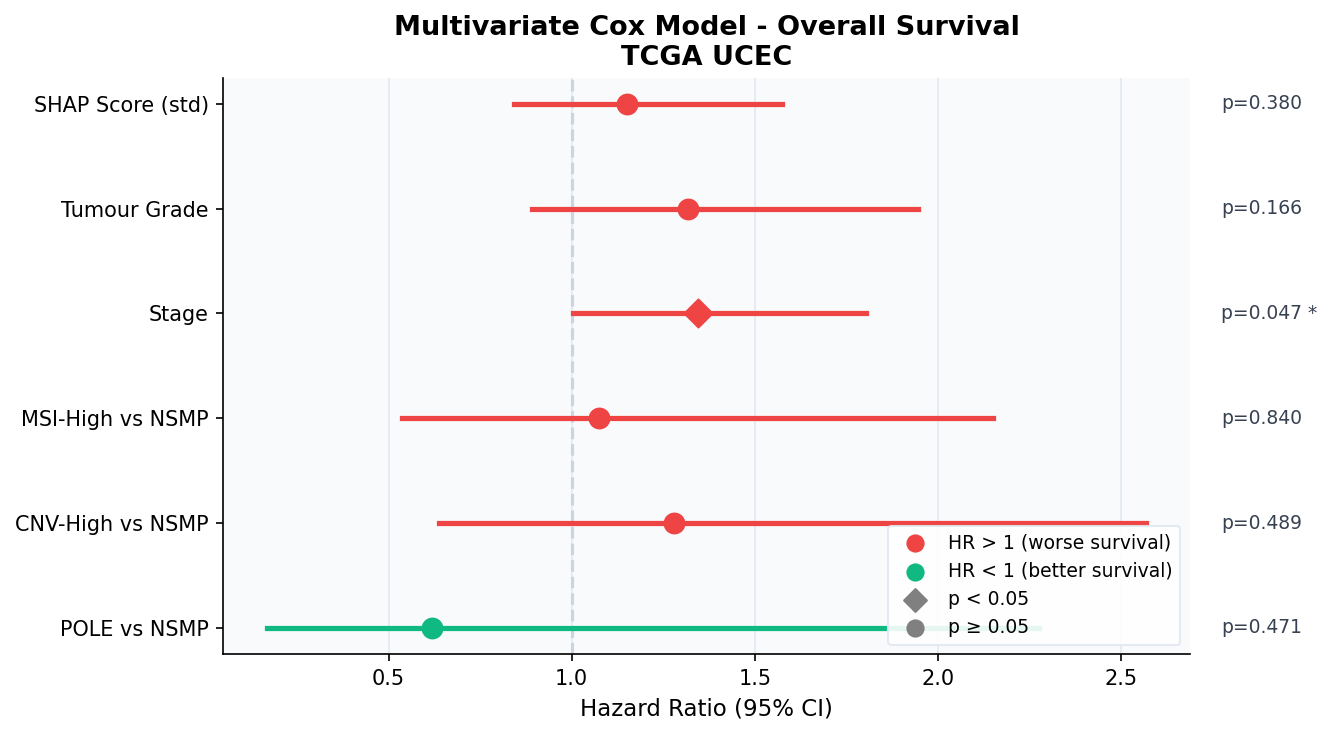

In [41]:
# Cox Forest Plot 
summary = cph.summary.copy()
summary['HR']    = np.exp(summary['coef'])
summary['HR_lo'] = np.exp(summary['coef lower 95%'])
summary['HR_hi'] = np.exp(summary['coef upper 95%'])

label_map = {
    'shap_score_std': 'SHAP Score (std)',
    'grade_num':      'Tumour Grade',
    'stage_num':      'Stage',
    'is_MSI':         'MSI-High vs NSMP',
    'is_CNV':         'CNV-High vs NSMP',
    'is_POLE':        'POLE vs NSMP',
}
summary.index = [label_map.get(i, i) for i in summary.index]

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = list(range(len(summary)))[::-1]

for i, (y, (idx, row)) in enumerate(zip(y_pos, summary.iterrows())):
    col    = '#EF4444' if row['HR'] > 1 else '#10B981'
    marker = 'D' if row['p'] < 0.05 else 'o'
    ax.plot([row['HR_lo'], row['HR_hi']], [y, y], color=col, lw=2.5, zorder=3)
    ax.scatter(row['HR'], y, color=col, s=90, zorder=4, marker=marker)
    pstr = f'p={row["p"]:.3f}' + (' *' if row['p'] < 0.05 else '')
    ax.text(summary['HR_hi'].max() * 1.08, y, pstr,
            va='center', fontsize=9, color='#374151')

ax.axvline(1, color='#CBD5E1', lw=1.5, ls='--', zorder=2)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary.index, fontsize=10)
ax.set_xlabel('Hazard Ratio (95% CI)', fontsize=11)
ax.set_title('Multivariate Cox Model - Overall Survival\nTCGA UCEC',
             fontsize=13, fontweight='bold')
ax.set_facecolor('#F8FAFC')
ax.xaxis.grid(True, color='#E2E8F0', zorder=0)

legend_elements = [
    plt.scatter([], [], color='#EF4444', s=60, label='HR > 1 (worse survival)'),
    plt.scatter([], [], color='#10B981', s=60, label='HR < 1 (better survival)'),
    plt.scatter([], [], color='gray',    s=60, marker='D', label='p < 0.05'),
    plt.scatter([], [], color='gray',    s=60, marker='o', label='p ≥ 0.05'),
]
ax.legend(handles=legend_elements, frameon=True, framealpha=0.9,
          edgecolor='#E2E8F0', fontsize=9, loc='lower right')

plt.tight_layout()
savefig('cox_forest.png')